Dataset Shape : (50000, 15)

First 5 Rows
  TransactionID AccountID  TransactionAmount   TransactionDate  \
0      TX000001   AC00128              14.09   4/11/2023 16:29   
1      TX000002   AC00455             376.24   6/27/2023 16:44   
2      TX000003   AC00019             126.29   7/10/2023 18:16   
3      TX000004   AC00070             184.50    5/5/2023 16:32   
4      TX000005   AC00411              13.45  10/16/2023 17:51   

  TransactionType   Location DeviceID      IP Address MerchantID Channel  \
0           Debit  San Diego  D000380  162.198.218.92       M015     ATM   
1           Debit    Houston  D000051     13.149.61.4       M052     ATM   
2           Debit       Mesa  D000235  215.97.143.157       M009  Online   
3           Debit    Raleigh  D000187  200.13.225.150       M002  Online   
4          Credit    Atlanta  D000308    65.164.3.100       M091  Online   

   CustomerAge CustomerOccupation  TransactionDuration  LoginAttempts  \
0           70             Doct

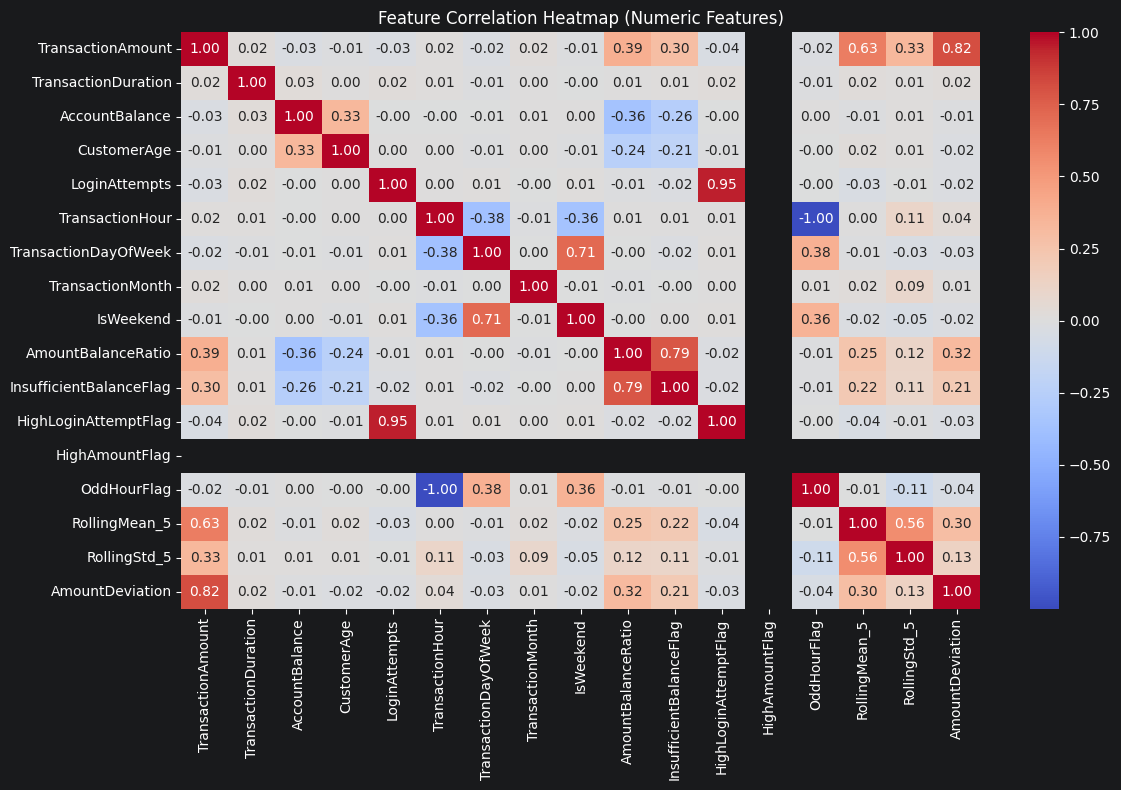


PCA shape: (6250, 2)

Isolation Forest Results
IsolationForest_Anomaly
0    6125
1     125
Name: count, dtype: int64

LOF Results
LOF_Anomaly
0    6125
1     125
Name: count, dtype: int64

DBSCAN Cluster Counts
DBSCAN_Cluster
-1    6227
 0       6
 1       7
 2       5
 3       5
Name: count, dtype: int64


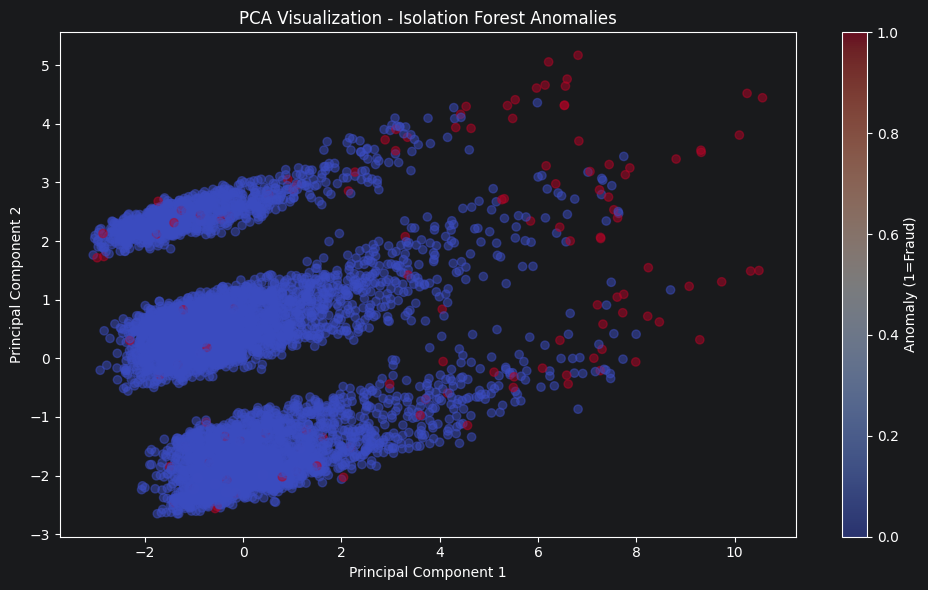


Final Dataset Preview (first 5 rows with anomaly flags)
     TransactionID AccountID  TransactionAmount  AccountBalance  \
3677      TX003678   AC00001              47.66         1649.92   
2922      TX002923   AC00001              43.31         1649.92   
5766      TX005767   AC00001             200.18         4180.40   
3309      TX003310   AC00001              46.83         1649.92   
1312      TX001313   AC00001              47.79         1649.92   

      IsolationForest_Anomaly  LOF_Anomaly  DBSCAN_Cluster  
3677                        0            0              -1  
2922                        0            0              -1  
5766                        0            0              -1  
3309                        0            1              -1  
1312                        0            0              -1  

✅ Feature engineering and anomaly detection completed successfully.


In [2]:
# ================================
# IMPORT LIBRARIES
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# ================================
# LOAD DATASET
# ================================

df = pd.read_csv(r'C:\Users\Nalavade\PycharmProjects\Fraud_Detection_Project\bank_transactions_data_2_augmented_clean.csv')

print("Dataset Shape :", df.shape)
print("\nFirst 5 Rows")
print(df.head())
print("\nDataset Information")
print(df.info())

# ================================
# CHECK MISSING VALUES
# ================================

print("\nMissing Values Before Imputation")
print(df.isnull().sum())

# ================================
# HANDLE MISSING VALUES
# ================================

# Numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
median_imputer = SimpleImputer(strategy='median')
df[numerical_cols] = median_imputer.fit_transform(df[numerical_cols])

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
mode_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = mode_imputer.fit_transform(df[categorical_cols])

print("\nMissing Values After Imputation")
print(df.isnull().sum())

# ================================
# CONVERT DATE COLUMN
# ================================

df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')
df = df.dropna(subset=['TransactionDate'])   # remove rows where conversion failed

# =========================================================
# FEATURE ENGINEERING FOR HYBRID FRAUD DETECTION
# =========================================================

# ---------------------------------------------------------
# TRANSACTION DATE FEATURES
# ---------------------------------------------------------
df['TransactionHour'] = df['TransactionDate'].dt.hour
df['TransactionDayOfWeek'] = df['TransactionDate'].dt.dayofweek
df['TransactionMonth'] = df['TransactionDate'].dt.month
df['IsWeekend'] = df['TransactionDayOfWeek'].isin([5, 6]).astype(int)

# ---------------------------------------------------------
# BUSINESS RULE FEATURES
# ---------------------------------------------------------
df['AmountBalanceRatio'] = df['TransactionAmount'] / (df['AccountBalance'] + 1)
df['InsufficientBalanceFlag'] = (df['TransactionAmount'] > df['AccountBalance']).astype(int)
df['HighLoginAttemptFlag'] = (df['LoginAttempts'] >= 3).astype(int)
df['HighAmountFlag'] = (df['TransactionAmount'] > 500000).astype(int)
df['OddHourFlag'] = ((df['TransactionHour'] < 5) | (df['TransactionHour'] > 23)).astype(int)

# ---------------------------------------------------------
# ROLLING TRANSACTION FEATURES (per account)
# ---------------------------------------------------------
df = df.sort_values(['AccountID', 'TransactionDate'])

df['RollingMean_5'] = df.groupby('AccountID')['TransactionAmount'].transform(
    lambda x: x.rolling(window=5, min_periods=1).mean()
)
df['RollingStd_5'] = df.groupby('AccountID')['TransactionAmount'].transform(
    lambda x: x.rolling(window=5, min_periods=1).std()
)
df['RollingStd_5'] = df['RollingStd_5'].fillna(0)

# ---------------------------------------------------------
# AMOUNT DEVIATION FROM ACCOUNT AVERAGE
# ---------------------------------------------------------
account_means = df.groupby('AccountID')['TransactionAmount'].transform('mean')
df['AmountDeviation'] = (df['TransactionAmount'] - account_means) / (account_means + 1)

# =========================================================
# SELECT NUMERIC FEATURES (all engineered + original numeric)
# =========================================================

numeric_features = [
    # Original/available numeric columns
    'TransactionAmount',
    'TransactionDuration',
    'AccountBalance',
    'CustomerAge',
    'LoginAttempts',
    # Time features
    'TransactionHour',
    'TransactionDayOfWeek',
    'TransactionMonth',
    'IsWeekend',
    # Business rule flags
    'AmountBalanceRatio',
    'InsufficientBalanceFlag',
    'HighLoginAttemptFlag',
    'HighAmountFlag',
    'OddHourFlag',
    # Rolling features
    'RollingMean_5',
    'RollingStd_5',
    'AmountDeviation'
]

# Remove any numeric feature that might not exist in the dataframe (safety check)
existing_numeric = [col for col in numeric_features if col in df.columns]
missing = set(numeric_features) - set(existing_numeric)
if missing:
    print(f"Warning: These columns are missing and will be skipped: {missing}")
numeric_features = existing_numeric

# =========================================================
# HANDLE INF / NaN IN NUMERIC FEATURES
# =========================================================
df[numeric_features] = df[numeric_features].replace([np.inf, -np.inf], np.nan)
df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())

# =========================================================
# ENCODE CATEGORICAL FEATURES
# =========================================================
categorical_features = ['TransactionType', 'Channel', 'Location']
df_encoded = pd.get_dummies(df[categorical_features], drop_first=True)

# =========================================================
# PREPARE FINAL FEATURE MATRIX
# =========================================================
X_numeric = df[numeric_features]
X_combined = pd.concat([X_numeric, df_encoded], axis=1)

print("\n====================================")
print("FINAL FEATURE MATRIX")
print("====================================")
print(f"Feature Matrix Shape: {X_combined.shape}")
print("\nFeature columns:")
print(X_combined.columns.tolist())

# =========================================================
# SCALE FEATURES
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# =========================================================
# SAVE FEATURE COLUMNS AND SCALER
# =========================================================
os.makedirs('models', exist_ok=True)
joblib.dump(X_combined.columns.tolist(), 'models/feature_columns.pkl')
joblib.dump(scaler, 'models/scaler_standard.pkl')
print("\nFeature columns and scaler saved to 'models/' directory.")

# =========================================================
# CORRELATION HEATMAP (on scaled numeric part only for clarity)
# =========================================================
scaled_numeric_df = pd.DataFrame(X_scaled[:, :len(numeric_features)], columns=numeric_features)

plt.figure(figsize=(12, 8))
sns.heatmap(scaled_numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

# =========================================================
# PCA FOR DIMENSIONALITY REDUCTION (2D visualization)
# =========================================================
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)
print(f"\nPCA shape: {pca_features.shape}")

# =========================================================
# ISOLATION FOREST
# =========================================================
iso_model = IsolationForest(n_estimators=100, contamination=0.02, random_state=42)
df['IsolationForest_Anomaly'] = iso_model.fit_predict(X_scaled)
# Map: 1 -> normal (0), -1 -> anomaly (1)
df['IsolationForest_Anomaly'] = df['IsolationForest_Anomaly'].map({1: 0, -1: 1})

print("\nIsolation Forest Results")
print(df['IsolationForest_Anomaly'].value_counts())

# ================================
# LOCAL OUTLIER FACTOR
# ================================
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
lof_predictions = lof_model.fit_predict(X_scaled)
df['LOF_Anomaly'] = pd.Series(lof_predictions).map({1: 0, -1: 1})

print("\nLOF Results")
print(df['LOF_Anomaly'].value_counts())

# ================================
# DBSCAN CLUSTERING
# ================================
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = dbscan_labels

print("\nDBSCAN Cluster Counts")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

# ================================
# PCA VISUALIZATION (colored by Isolation Forest anomalies)
# ================================
plt.figure(figsize=(10, 6))
scatter = plt.scatter(pca_features[:, 0], pca_features[:, 1],
                      c=df['IsolationForest_Anomaly'], cmap='coolwarm', alpha=0.5)
plt.colorbar(scatter, label='Anomaly (1=Fraud)')
plt.title("PCA Visualization - Isolation Forest Anomalies")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

# ================================
# FINAL OUTPUT PREVIEW
# ================================
print("\nFinal Dataset Preview (first 5 rows with anomaly flags)")
print(df[['TransactionID', 'AccountID', 'TransactionAmount', 'AccountBalance',
          'IsolationForest_Anomaly', 'LOF_Anomaly', 'DBSCAN_Cluster']].head())

print("\n✅ Feature engineering and anomaly detection completed successfully.")

In [3]:
df['HighAmountFlag'].isnull().sum()

np.int64(0)

In [4]:
df['HighAmountFlag'].nunique()

1

In [5]:
df['HighAmountFlag'].dtype

dtype('int64')

Statistical Summary of Numerical Features:
       TransactionAmount  TransactionDuration  AccountBalance  CustomerAge  \
count        6250.000000          6250.000000     6250.000000  6250.000000   
mean          291.765517           118.732000     5124.276978    44.599360   
std           289.044477            69.479829     3930.253201    17.787408   
min             0.250000            10.000000      101.250000    18.000000   
25%            80.280000            63.000000     1485.732500    27.000000   
50%           203.370000           112.000000     4725.540000    45.000000   
75%           397.307500           161.000000     7713.670000    59.000000   
max          1946.710000           300.000000    14977.990000    80.000000   

       LoginAttempts  TransactionHour  TransactionDayOfWeek  TransactionMonth  \
count    6250.000000      6250.000000           6250.000000       6250.000000   
mean        1.122720         6.682400              2.347520          6.618720   
std        

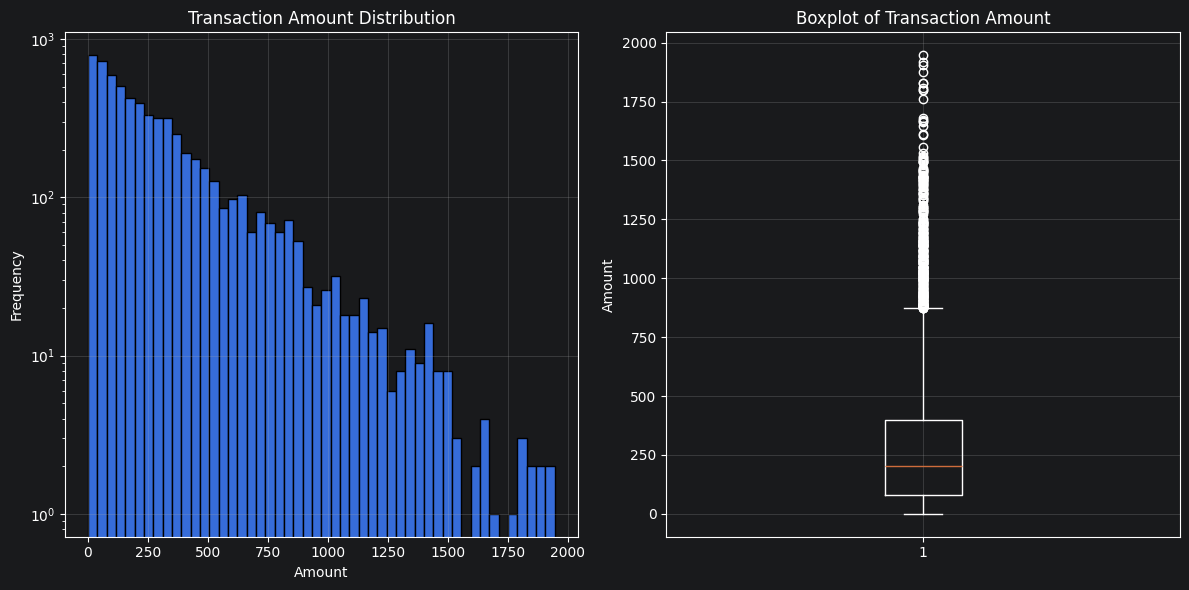

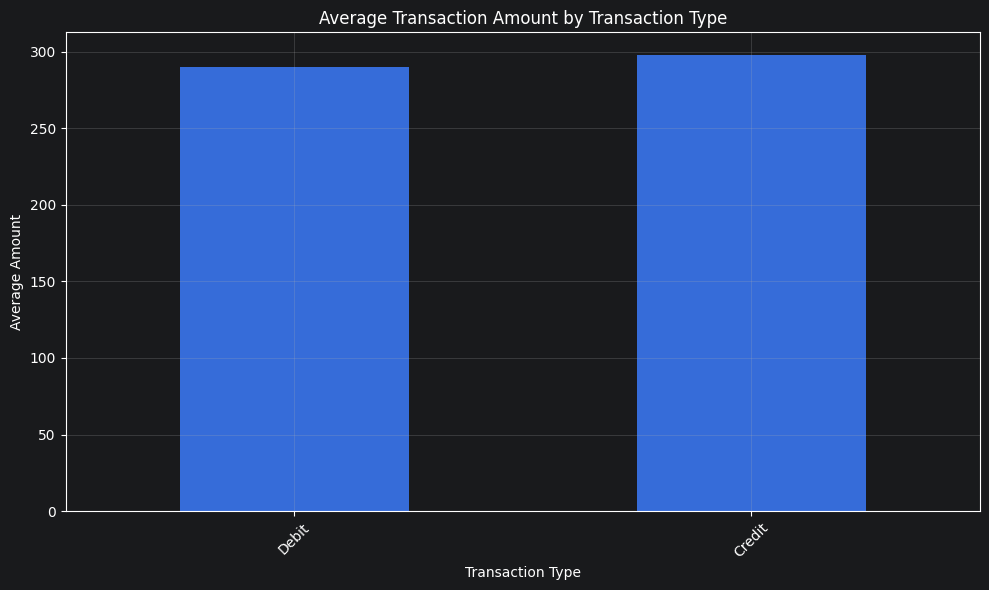

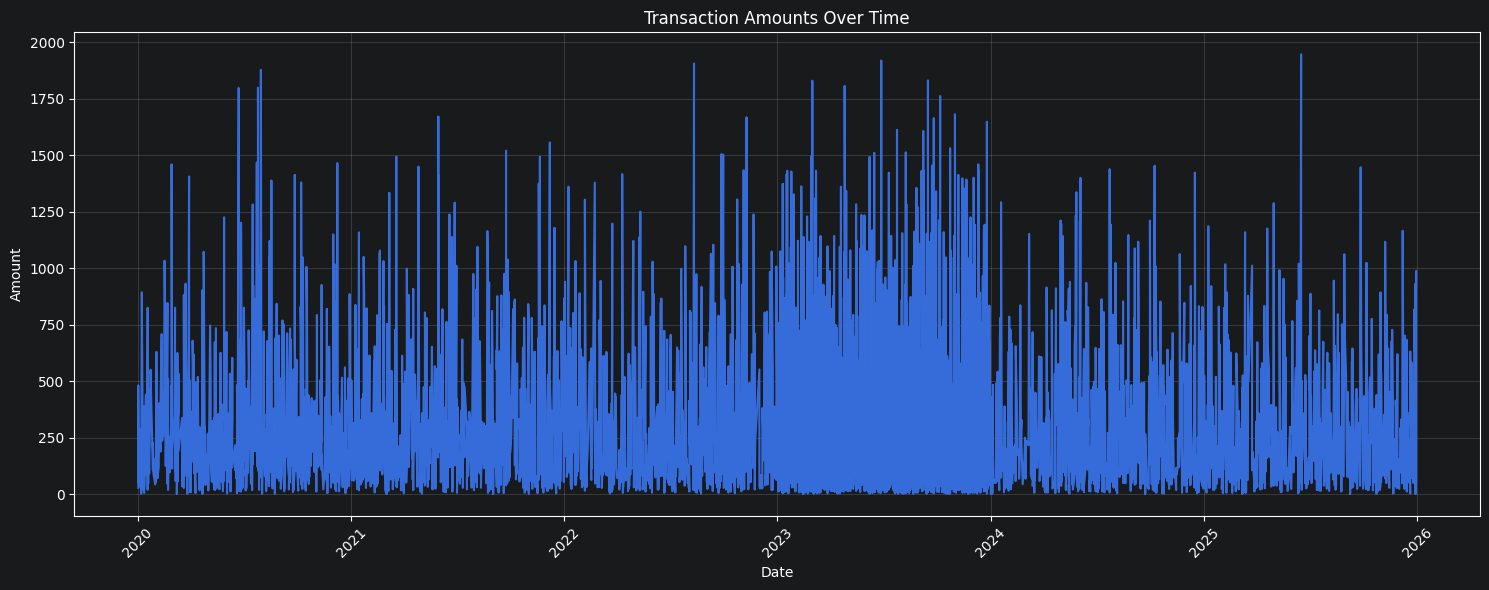

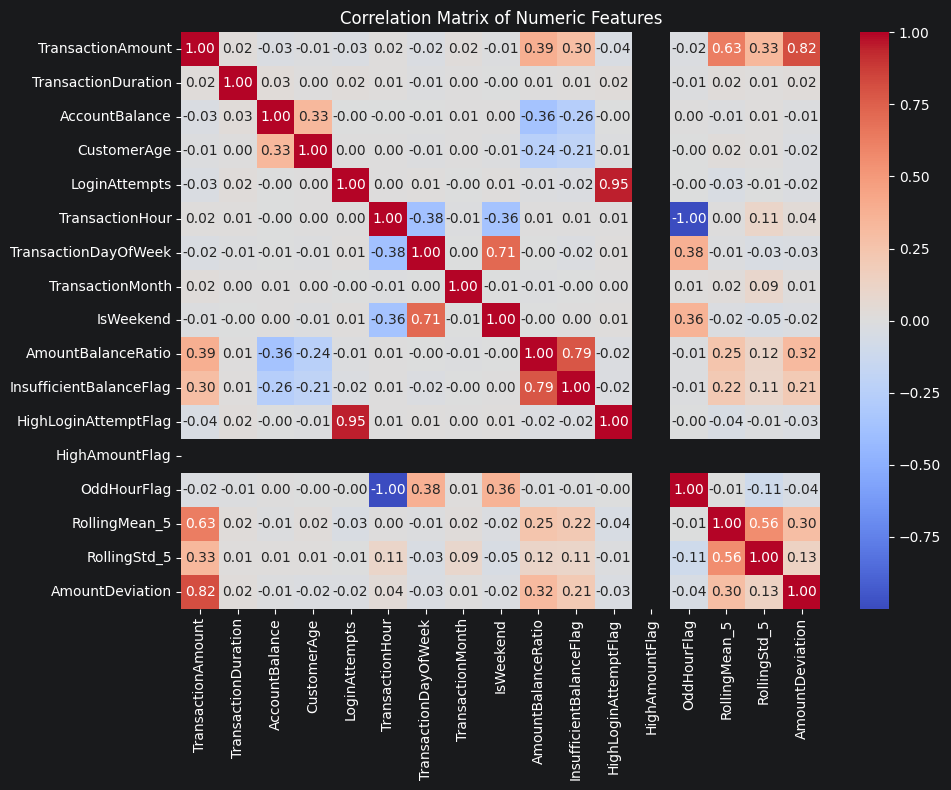

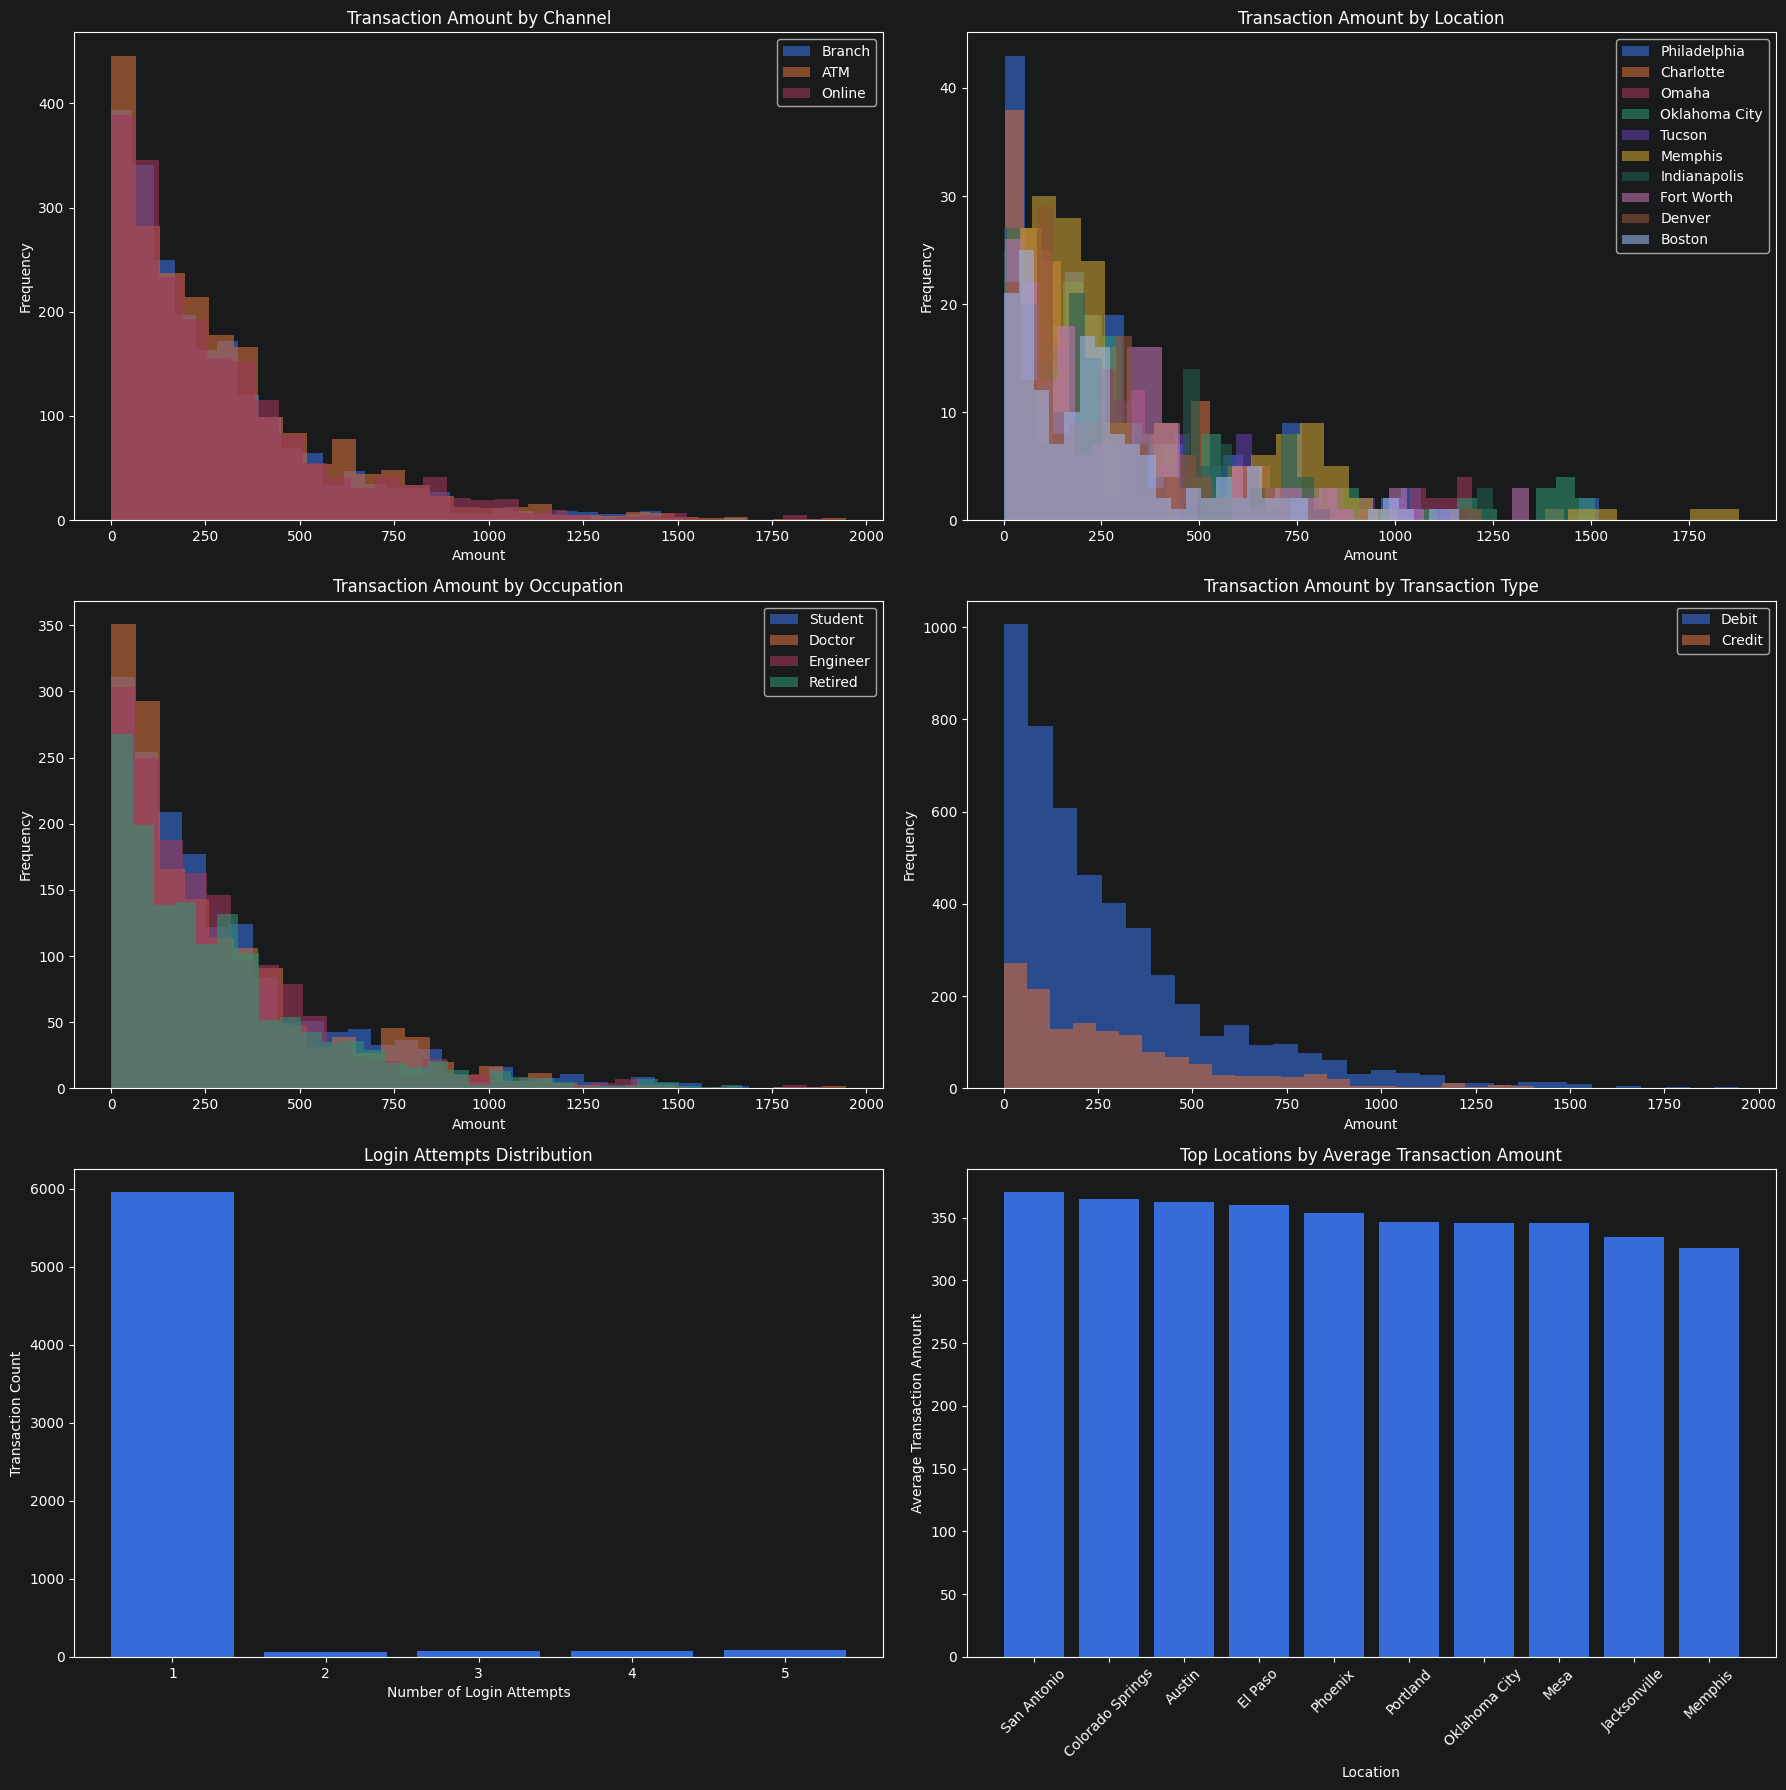

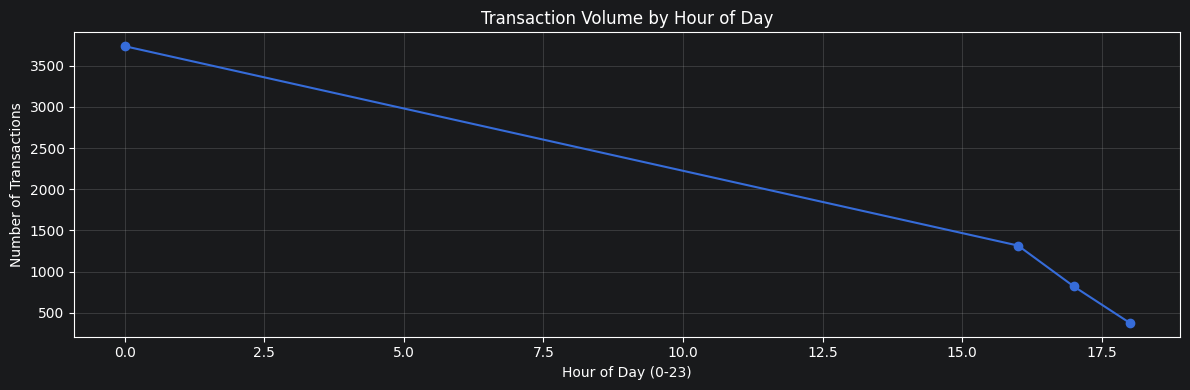

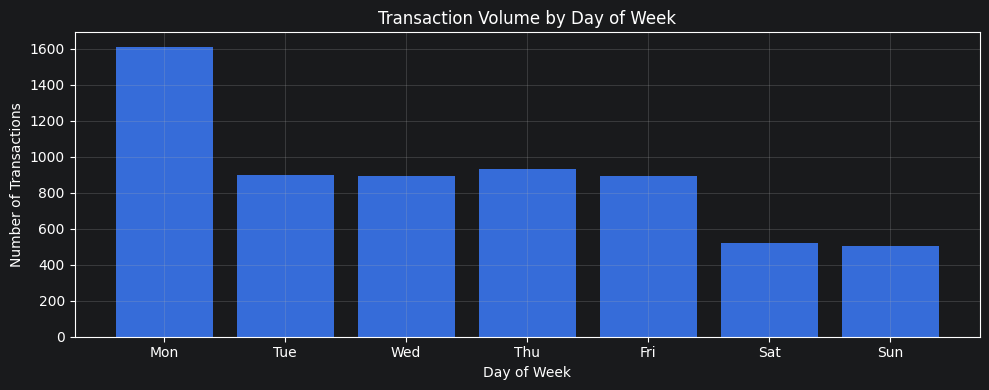

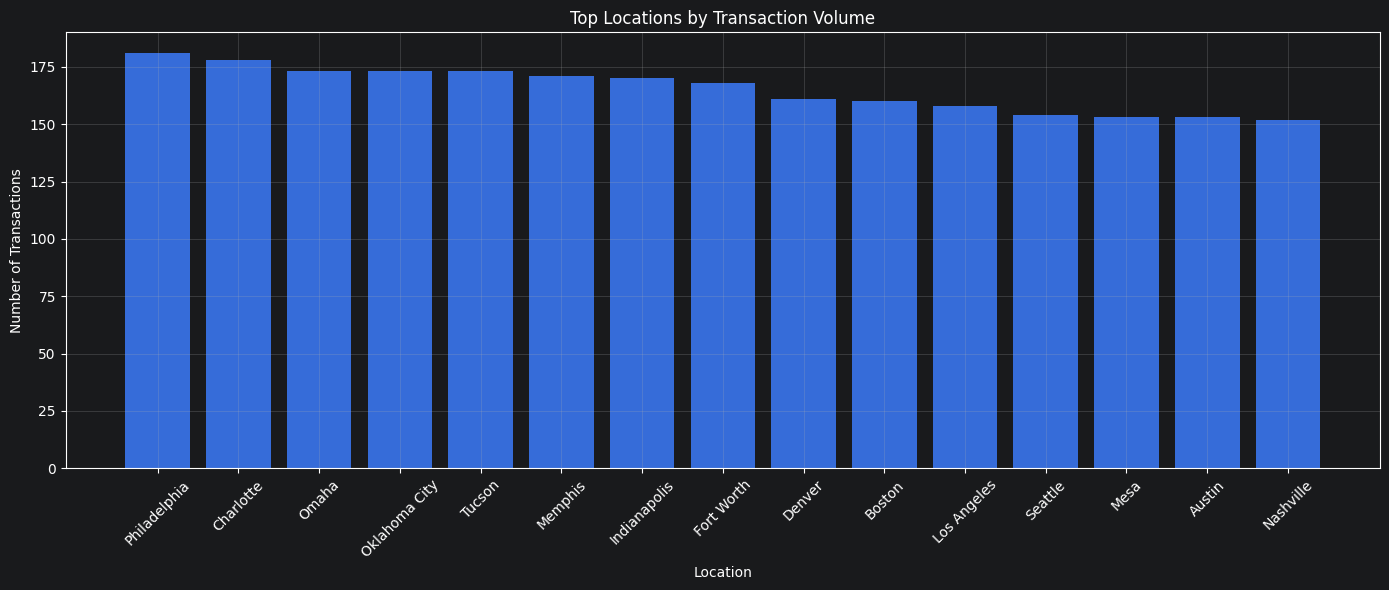


Location-wise Transaction Analysis:
                 TransactionAmount                LoginAttempts
                              mean      max count          mean
Location                                                       
Albuquerque             227.075446  1021.16   101      1.118812
Atlanta                 241.728828  1233.79   145      1.179310
Austin                  362.092549  1397.59   153      1.130719
Baltimore               302.000536  1192.98   112      1.071429
Boston                  257.996625  1164.30   160      1.012500
Charlotte               230.271292  1431.33   178      1.073034
Chicago                 264.514589   836.06   146      1.157534
Colorado Springs        364.673165  1493.00   139      1.165468
Columbus                314.632535  1831.02   142      1.084507
Dallas                  195.848534   896.79   116      1.129310


In [6]:
# ================================
# Basic statistics
# ================================

print("Statistical Summary of Numerical Features:")
print(df[numeric_features].describe())

# ================================
# Distribution of Transaction Amount
# ================================

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)

plt.hist(
    df['TransactionAmount'],
    bins=50,
    edgecolor='black'
)

plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)

plt.boxplot(df['TransactionAmount'])

plt.title('Boxplot of Transaction Amount')
plt.ylabel('Amount')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ================================
# Transaction Amount by Transaction Type
# ================================

plt.figure(figsize=(10, 6))

df.groupby('TransactionType')['TransactionAmount'] \
    .mean() \
    .sort_values() \
    .plot(kind='bar')

plt.title('Average Transaction Amount by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Average Amount')

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ================================
# Transaction Amount over Time
# ================================

sorted_df = df.sort_values('TransactionDate')

plt.figure(figsize=(15, 6))

plt.plot(
    sorted_df['TransactionDate'],
    sorted_df['TransactionAmount']
)

plt.title('Transaction Amounts Over Time')
plt.xlabel('Date')
plt.ylabel('Amount')

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ================================
# Correlation Matrix
# ================================

plt.figure(figsize=(10, 8))

correlation_matrix = df[numeric_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Correlation Matrix of Numeric Features')

plt.tight_layout()
plt.show()

# ================================
# Anomaly Detection Across Categories
# ================================

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# --------------------------------
# By Channel
# --------------------------------

channels = df['Channel'].value_counts().head(10).index

for channel in channels:

    channel_data = df[
        df['Channel'] == channel
    ]['TransactionAmount']

    axes[0, 0].hist(
        channel_data,
        bins=30,
        alpha=0.6,
        label=channel
    )

axes[0, 0].set_title('Transaction Amount by Channel')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# --------------------------------
# By Location
# --------------------------------

locations = df['Location'].value_counts().head(10).index

for location in locations:

    location_data = df[
        df['Location'] == location
    ]['TransactionAmount']

    axes[0, 1].hist(
        location_data,
        bins=30,
        alpha=0.6,
        label=location
    )

axes[0, 1].set_title('Transaction Amount by Location')
axes[0, 1].set_xlabel('Amount')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# --------------------------------
# By Customer Occupation
# --------------------------------

occupations = df['CustomerOccupation'].value_counts().head(5).index

for occupation in occupations:

    occupation_data = df[
        df['CustomerOccupation'] == occupation
    ]['TransactionAmount']

    axes[1, 0].hist(
        occupation_data,
        bins=30,
        alpha=0.6,
        label=occupation
    )

axes[1, 0].set_title('Transaction Amount by Occupation')
axes[1, 0].set_xlabel('Amount')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# --------------------------------
# By Transaction Type
# --------------------------------

trans_types = df['TransactionType'].value_counts().head(10).index

for trans_type in trans_types:

    type_data = df[
        df['TransactionType'] == trans_type
    ]['TransactionAmount']

    axes[1, 1].hist(
        type_data,
        bins=30,
        alpha=0.6,
        label=trans_type
    )

axes[1, 1].set_title('Transaction Amount by Transaction Type')
axes[1, 1].set_xlabel('Amount')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

# --------------------------------
# Login Attempts Analysis
# --------------------------------

login_attempts_dist = df['LoginAttempts'] \
    .value_counts() \
    .sort_index()

axes[2, 0].bar(
    login_attempts_dist.index,
    login_attempts_dist.values
)

axes[2, 0].set_title('Login Attempts Distribution')
axes[2, 0].set_xlabel('Number of Login Attempts')
axes[2, 0].set_ylabel('Transaction Count')

# --------------------------------
# Average Transaction Amount by Location
# --------------------------------

location_avg = df.groupby('Location')['TransactionAmount'] \
    .mean() \
    .sort_values(ascending=False) \
    .head(10)

axes[2, 1].bar(
    location_avg.index,
    location_avg.values
)

axes[2, 1].set_title('Top Locations by Average Transaction Amount')
axes[2, 1].set_xlabel('Location')
axes[2, 1].set_ylabel('Average Transaction Amount')

axes[2, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ================================
# Time-based Analysis
# ================================

# --------------------------------
# Transaction Volume by Hour
# --------------------------------

df_by_hour = df.groupby('TransactionHour').size()

plt.figure(figsize=(12, 4))

plt.plot(
    df_by_hour.index,
    df_by_hour.values,
    marker='o'
)

plt.title('Transaction Volume by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Transactions')

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --------------------------------
# Transaction Volume by Day of Week
# --------------------------------

df_by_day = df.groupby('TransactionDayOfWeek').size()

plt.figure(figsize=(10, 4))

plt.bar(
    df_by_day.index,
    df_by_day.values
)

plt.title('Transaction Volume by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')

plt.xticks(
    range(7),
    ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ================================
# Location-wise Transaction Volume
# ================================

location_volume = df['Location'].value_counts().head(15)

plt.figure(figsize=(14, 6))

plt.bar(
    location_volume.index,
    location_volume.values
)

plt.title('Top Locations by Transaction Volume')
plt.xlabel('Location')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ================================
# Fraud Pattern Logic by Location
# ================================

location_stats = df.groupby('Location').agg({
    'TransactionAmount': ['mean', 'max', 'count'],
    'LoginAttempts': 'mean'
})

print("\nLocation-wise Transaction Analysis:")
print(location_stats.head(10))

In [7]:
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)
# ================================
# CREATE ACCOUNT LEVEL FEATURES
# ================================

account_features = df.groupby('AccountID').agg({
    'TransactionAmount': [
        'mean',
        'std',
        'min',
        'max',
        'count',
        lambda x: x.quantile(0.95)
    ],

    'TransactionDuration': [
        'mean',
        'std'
    ],

    'Channel': lambda x: x.nunique(),

    'Location': lambda x: x.nunique(),

    'TransactionDate': lambda x: (
        x.max() - x.min()
    ).days
})

# ================================
# RENAME MULTI-INDEX COLUMNS
# ================================

account_features.columns = [
    '_'.join(col).strip()
    for col in account_features.columns.values
]

# ================================
# RENAME LAMBDA COLUMNS
# ================================

account_features = account_features.rename(columns={
    'TransactionAmount_<lambda_0>':
        'TransactionAmount_95th_percentile',

    'TransactionDate_<lambda>':
        'TransactionHistoryLength_days',

    'TransactionDate_<lambda_0>':
        'TransactionHistoryLength_days',

    'Channel_<lambda>':
        'UniqueChannelsUsed',

    'Channel_<lambda_0>':
        'UniqueChannelsUsed',

    'Location_<lambda>':
        'UniqueLocationsUsed',

    'Location_<lambda_0>':
        'UniqueLocationsUsed'
})

# ================================
# HANDLE MISSING VALUES
# ================================

account_features = account_features.fillna(
    account_features.median(numeric_only=True)
)

print("\nAccount Level Features Shape:")
print(account_features.shape)

print("\nAccount Feature Preview")
print(account_features.head())

# ================================
# SORT DATA FOR TIME SERIES
# ================================

df = df.sort_values(
    by=['AccountID', 'TransactionDate']
)

# ================================
# ROLLING STATISTICS
# ================================

df['RollingMean_5'] = df.groupby('AccountID')[
    'TransactionAmount'
].transform(
    lambda x: x.rolling(
        window=5,
        min_periods=1
    ).mean()
)

df['RollingStd_5'] = df.groupby('AccountID')[
    'TransactionAmount'
].transform(
    lambda x: x.rolling(
        window=5,
        min_periods=1
    ).std()
)

# Fill NaN created from std calculation
df['RollingStd_5'] = df['RollingStd_5'].fillna(0)

# ================================
# WEEKEND FLAG
# ================================

df['IsWeekend'] = df[
    'TransactionDayOfWeek'
].isin([5, 6]).astype(int)

# ================================
# AMOUNT DEVIATION FEATURE
# ================================

account_means = df.groupby('AccountID')[
    'TransactionAmount'
].transform('mean')

df['AmountDeviation'] = (
    df['TransactionAmount'] - account_means
) / (account_means + 1)

# ================================
# UPDATE NUMERIC FEATURES
# ================================

numeric_features_extended = numeric_features + [
    'RollingMean_5',
    'RollingStd_5',
    'AmountDeviation'
]

# ================================
# PREPARE FEATURES
# ================================

X = df[numeric_features_extended].copy()

# ================================
# ENCODE CATEGORICAL VARIABLES
# ================================

categorical_columns = [
    'TransactionType',
    'Channel',
    'Location'
]

df_encoded = pd.get_dummies(
    df[categorical_columns],
    drop_first=True
)

# ================================
# COMBINE FEATURES
# ================================

X_combined = pd.concat(
    [X, df_encoded],
    axis=1
)

# ================================
# REMOVE INF/NAN VALUES
# ================================

X_combined = X_combined.replace(
    [np.inf, -np.inf],
    np.nan
)

X_combined = X_combined.fillna(
    X_combined.median(numeric_only=True)
)

# ================================
# STANDARDIZATION
# ================================

scaler_standard = StandardScaler()

X_standard = scaler_standard.fit_transform(
    X_combined
)

# ================================
# ROBUST SCALING
# ================================

scaler_robust = RobustScaler()

X_robust = scaler_robust.fit_transform(
    X_combined
)

# ================================
# MIN-MAX NORMALIZATION
# ================================

scaler_minmax = MinMaxScaler()

X_normalized = scaler_minmax.fit_transform(
    X_combined
)

print("\nStandardized Data Shape:")
print(X_standard.shape)

print("\nNormalized Data Shape:")
print(X_normalized.shape)

# ================================
# CREATE SEQUENCES FOR LSTM
# ================================

def create_sequences(data, seq_length):

    X_seq = []

    for i in range(len(data) - seq_length):

        X_seq.append(
            data[i:i + seq_length]
        )

    return np.array(X_seq)

# ================================
# SEQUENCE LENGTH
# ================================

sequence_length = 10

X_sequence = create_sequences(
    X_standard,
    sequence_length
)

print("\nLSTM Sequence Shape:")
print(X_sequence.shape)


Account Level Features Shape:
(495, 11)

Account Feature Preview
           TransactionAmount_mean  TransactionAmount_std  \
AccountID                                                  
AC00001                 82.566667              70.401790   
AC00002                325.446316             192.291774   
AC00003                278.390000             148.549030   
AC00004                237.329565             214.479008   
AC00005                349.563333             165.776329   

           TransactionAmount_min  TransactionAmount_max  \
AccountID                                                 
AC00001                    43.31                 212.97   
AC00002                    10.63                 526.79   
AC00003                    20.17                 416.62   
AC00004                    12.85                 679.79   
AC00005                   107.48                 680.76   

           TransactionAmount_count  TransactionAmount_95th_percentile  \
AccountID                 

# =========================================================
# ISOLATION FOREST FRAUD DETECTION MODEL
# =========================================================


FEATURE MATRIX INFORMATION
Shape of X_standard: (6250, 65)

TRAINING ISOLATION FOREST

ISOLATION FOREST RESULTS
Total Transactions: 6250
Anomalies Detected: 313
Anomaly Percentage: 5.01%

RESULT PREVIEW
   AnomalyScore  IsolationForest_Anomaly
0      0.364738                        0
1      0.382171                        0
2      0.368060                        0
3      0.375236                        0
4      0.367283                        0


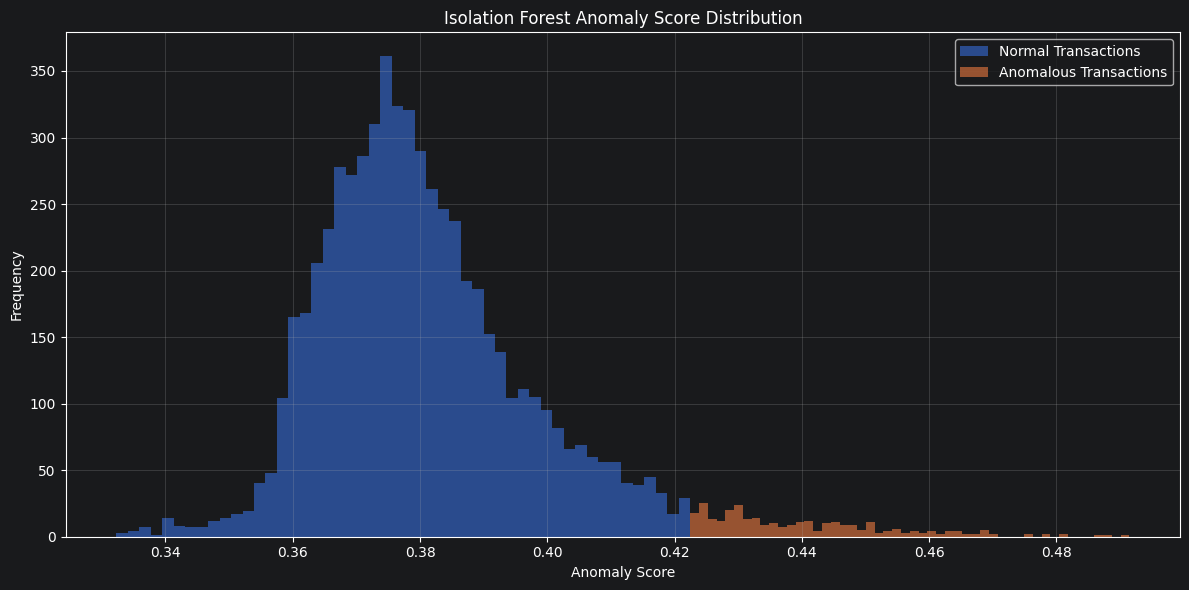

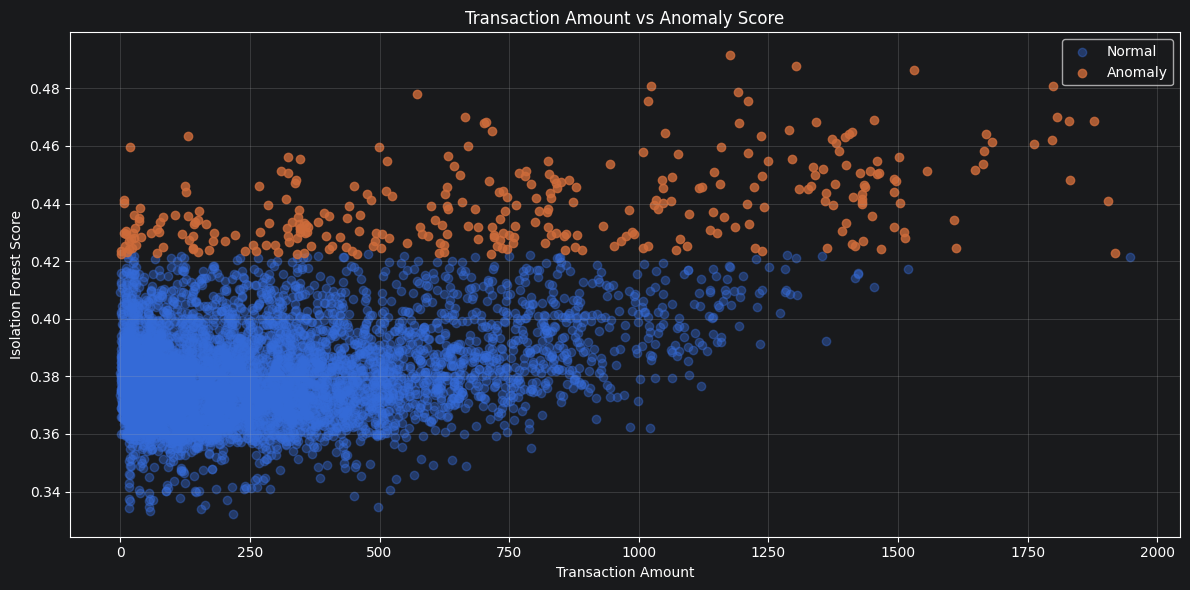


TOP ANOMALOUS TRANSACTIONS
      TransactionAmount  AccountBalance  LoginAttempts TransactionType  \
274             1176.28          323.69            5.0          Credit   
6021            1302.96          694.03            1.0          Credit   
898             1531.31          859.86            4.0           Debit   
934             1022.75          207.74            1.0          Credit   
5327            1798.76         2235.70            1.0           Debit   
1213            1192.20         7816.41            5.0          Credit   
4685             572.08          421.93            5.0           Debit   
5320            1210.41         7816.41            5.0          Credit   
3740            1018.31          207.74            1.0          Credit   
5456             665.33          164.61            1.0          Credit   

     Channel      Location  IsolationForest_Score  
274      ATM   Kansas City               0.491475  
6021  Branch    Fort Worth               0.487775  
8

In [8]:
# =========================================================
# VERIFY FEATURE MATRIX
# =========================================================

print("\n====================================")
print("FEATURE MATRIX INFORMATION")
print("====================================")

print(
    f"Shape of X_standard: "
    f"{X_standard.shape}"
)

# =========================================================
# BUILD ISOLATION FOREST MODEL
# =========================================================

iso_forest = IsolationForest(

    # -----------------------------------------------------
    # EXPECTED ANOMALY PERCENTAGE
    # -----------------------------------------------------

    contamination=0.05,

    # -----------------------------------------------------
    # NUMBER OF TREES
    # -----------------------------------------------------

    n_estimators=200,

    # -----------------------------------------------------
    # RANDOM STATE FOR REPRODUCIBILITY
    # -----------------------------------------------------

    random_state=42,

    # -----------------------------------------------------
    # USE ALL CPU CORES
    # -----------------------------------------------------

    n_jobs=-1
)

# =========================================================
# TRAIN MODEL
# =========================================================

print("\n====================================")
print("TRAINING ISOLATION FOREST")
print("====================================")

iso_forest.fit(
    X_standard
)

# =========================================================
# GENERATE PREDICTIONS
# =========================================================

iso_predictions = iso_forest.predict(
    X_standard
)

# =========================================================
# CONVERT PREDICTIONS TO BOOLEAN
# =========================================================

# -1 = anomaly
#  1 = normal

iso_forest_anomalies = (

    iso_predictions == -1
)

# =========================================================
# CALCULATE ANOMALY SCORES
# =========================================================

# More negative score = more anomalous

iso_scores = (

    -iso_forest.score_samples(
        X_standard
    )
)

# =========================================================
# DISPLAY RESULTS
# =========================================================

total_anomalies = np.sum(
    iso_forest_anomalies
)

anomaly_percentage = (

    np.mean(
        iso_forest_anomalies
    ) * 100
)

print("\n====================================")
print("ISOLATION FOREST RESULTS")
print("====================================")

print(
    f"Total Transactions: "
    f"{len(df)}"
)

print(
    f"Anomalies Detected: "
    f"{total_anomalies}"
)

print(
    f"Anomaly Percentage: "
    f"{anomaly_percentage:.2f}%"
)

# =========================================================
# CREATE RESULT DATAFRAME
# =========================================================
iso_results = pd.DataFrame({

    'AnomalyScore': iso_scores,

    'IsolationForest_Anomaly':

        iso_forest_anomalies.astype(int)
})

# =========================================================
# SHOW RESULT PREVIEW
# =========================================================

print("\n====================================")
print("RESULT PREVIEW")
print("====================================")

print(
    iso_results.head()
)

# =========================================================
# ADD RESULTS TO ORIGINAL DATAFRAME
# =========================================================

df['IsolationForest_Anomaly'] = (

    iso_forest_anomalies.astype(int)
)

df['IsolationForest_Score'] = (
    iso_scores
)

# =========================================================
# VISUALIZE ANOMALY SCORE DISTRIBUTION
# =========================================================

plt.figure(figsize=(12, 6))

# ---------------------------------------------------------
# NORMAL TRANSACTIONS
# ---------------------------------------------------------

plt.hist(

    iso_scores[
        ~iso_forest_anomalies
    ],

    bins=50,

    alpha=0.6,

    label='Normal Transactions'
)

# ---------------------------------------------------------
# ANOMALOUS TRANSACTIONS
# ---------------------------------------------------------

plt.hist(

    iso_scores[
        iso_forest_anomalies
    ],

    bins=50,

    alpha=0.7,

    label='Anomalous Transactions'
)

# ---------------------------------------------------------
# CHART SETTINGS
# ---------------------------------------------------------

plt.title(
    'Isolation Forest Anomaly Score Distribution'
)

plt.xlabel(
    'Anomaly Score'
)

plt.ylabel(
    'Frequency'
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# =========================================================
# VISUALIZE TRANSACTION AMOUNT VS ANOMALIES
# =========================================================

plt.figure(figsize=(12, 6))

# ---------------------------------------------------------
# NORMAL TRANSACTIONS
# ---------------------------------------------------------

plt.scatter(

    df.loc[
        ~iso_forest_anomalies,
        'TransactionAmount'
    ],

    df.loc[
        ~iso_forest_anomalies,
        'IsolationForest_Score'
    ],

    alpha=0.4,

    label='Normal'
)

# ---------------------------------------------------------
# ANOMALOUS TRANSACTIONS
# ---------------------------------------------------------

plt.scatter(

    df.loc[
        iso_forest_anomalies,
        'TransactionAmount'
    ],

    df.loc[
        iso_forest_anomalies,
        'IsolationForest_Score'
    ],

    alpha=0.8,

    label='Anomaly'
)

# ---------------------------------------------------------
# CHART SETTINGS
# ---------------------------------------------------------

plt.title(
    'Transaction Amount vs Anomaly Score'
)

plt.xlabel(
    'Transaction Amount'
)

plt.ylabel(
    'Isolation Forest Score'
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# =========================================================
# TOP ANOMALOUS TRANSACTIONS
# =========================================================

top_anomalies = df[

    df['IsolationForest_Anomaly'] == 1

].sort_values(

    by='IsolationForest_Score',

    ascending=False
)

print("\n====================================")
print("TOP ANOMALOUS TRANSACTIONS")
print("====================================")

print(

    top_anomalies[[

        'TransactionAmount',

        'AccountBalance',

        'LoginAttempts',

        'TransactionType',

        'Channel',

        'Location',

        'IsolationForest_Score'

    ]].head(10)
)

# =========================================================
# SAVE MODEL
# =========================================================

import os
import joblib

os.makedirs(
    'models',
    exist_ok=True
)

joblib.dump(

    iso_forest,

    'models/isolation_forest.pkl'
)

print("\n====================================")
print("ISOLATION FOREST MODEL SAVED")
print("====================================")

print(
    "Saved Path: "
    "models/isolation_forest.pkl"
)


SEQUENCE DATA SHAPE
(6240, 10, 65)

FINAL LSTM INPUT SHAPE
Samples: 6240
Sequence Length: 10
Features: 65

TRAINING DATA SHAPE
(4992, 10, 65)

VALIDATION DATA SHAPE
(1248, 10, 65)

LSTM AUTOENCODER SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 10, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 65)         │         4,225 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,073 (324.50 KB)

 Trainable params: 83,073 (324.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 0.9710 - val_loss: 0.9590
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.9536 - val_loss: 0.9469
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.9431 - val_loss: 0.9384
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.9353 - val_loss: 0.9334
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.9302 - val_loss: 0.9298
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.9259 - val_loss: 0.9256
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.9227 - val_loss: 0.9234
Epoch 8/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.9193 - val_loss: 0.9204
Epoch 9/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.9161 - val_loss: 0.9198
Epoch 10/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.9141 - val_loss: 0.9178
Epoch 11/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.9120 - val_loss: 0.9152
Epoch 12/50
156/156 ━━━━━━━━━━━━━━━━━━━━

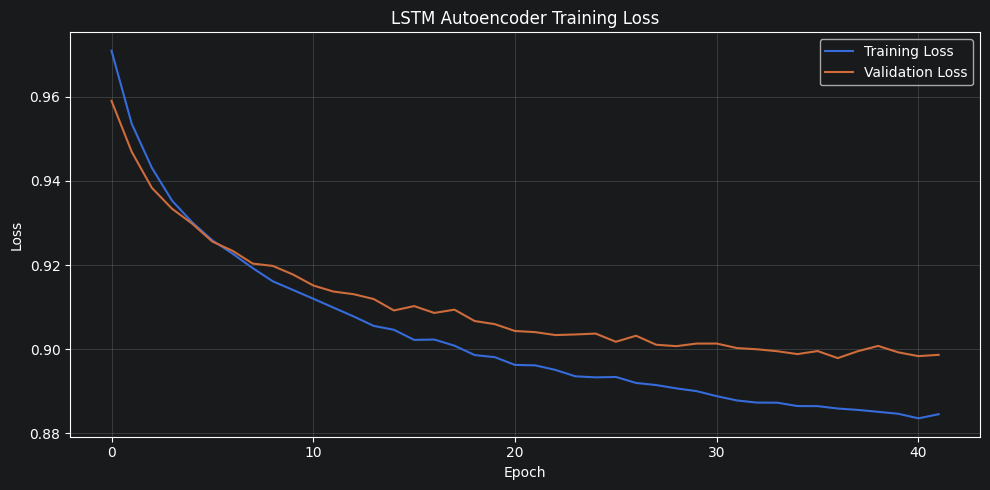

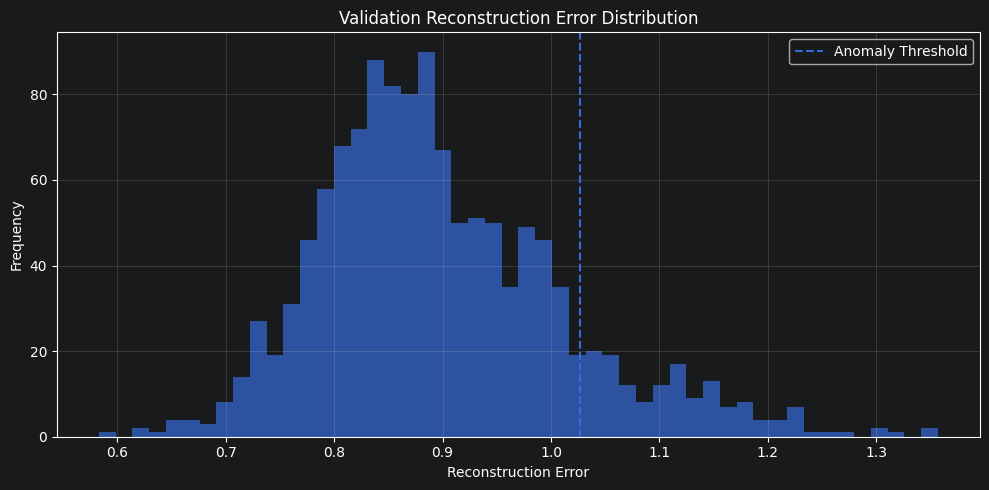

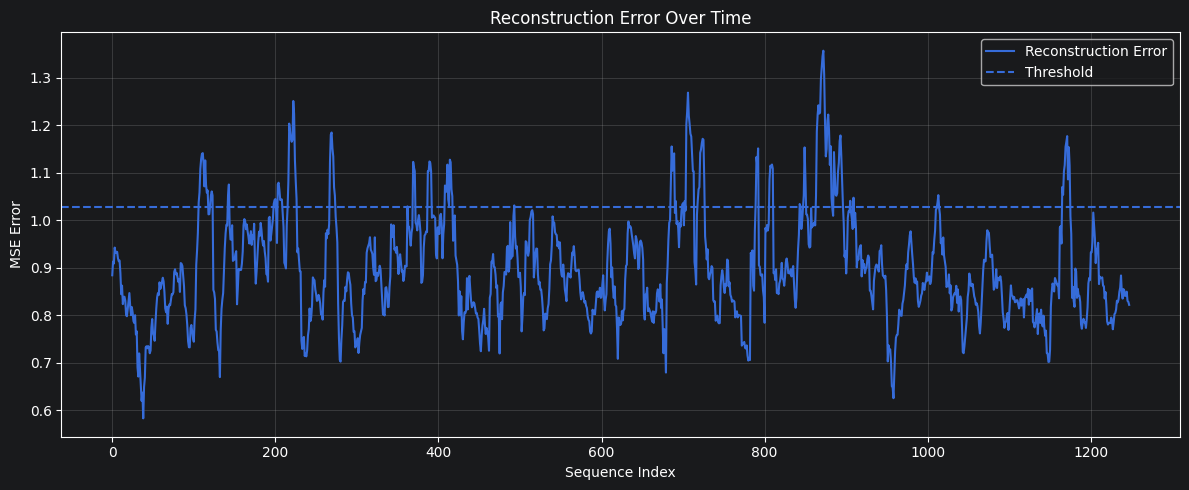


LSTM RESULT PREVIEW
   ReconstructionError  LSTM_Anomaly
0             0.884165             0
1             0.913269             0
2             0.908802             0
3             0.942453             0
4             0.931104             0

LSTM MODEL SAVED SUCCESSFULLY
Saved Path: models/lstm_autoencoder.keras


In [9]:
# =========================================================
# IMPORT REQUIRED LIBRARIES
# =========================================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    RepeatVector,
    TimeDistributed
)

from tensorflow.keras.callbacks import EarlyStopping

# =========================================================
# CREATE LSTM SEQUENCES
# =========================================================

def create_sequences(data, seq_length):

    sequences = []

    for i in range(

        len(data) - seq_length
    ):

        sequences.append(

            data[i:i + seq_length]
        )

    return np.array(sequences)

# =========================================================
# DEFINE SEQUENCE LENGTH
# =========================================================

sequence_length = 10

# =========================================================
# CREATE SEQUENTIAL DATA
# =================================================
X_sequence = create_sequences(

    X_standard,

    sequence_length
)

# =========================================================
# VERIFY SEQUENCE SHAPE
# =========================================================

print("\n====================================")
print("SEQUENCE DATA SHAPE")
print("====================================")

print(X_sequence.shape)

# =========================================================
# ENSURE NUMPY ARRAY
# =========================================================

X_sequence = np.array(
    X_sequence
)

# =========================================================
# VERIFY FINAL INPUT SHAPE
# =========================================================

print("\n====================================")
print("FINAL LSTM INPUT SHAPE")
print("====================================")

print(
    f"Samples: {X_sequence.shape[0]}"
)

print(
    f"Sequence Length: {X_sequence.shape[1]}"
)

print(
    f"Features: {X_sequence.shape[2]}"
)

# =========================================================
# TRAIN / VALIDATION SPLIT
# =========================================================

train_size = int(

    0.8 * len(X_sequence)
)

X_train_seq = X_sequence[:train_size]

X_val_seq = X_sequence[train_size:]

# =========================================================
# VERIFY TRAIN-VALIDATION SHAPES
# =========================================================

print("\n====================================")
print("TRAINING DATA SHAPE")
print("====================================")

print(X_train_seq.shape)

print("\n====================================")
print("VALIDATION DATA SHAPE")
print("====================================")

print(X_val_seq.shape)

# =========================================================
# BUILD LSTM AUTOENCODER
# =========================================================

def build_lstm_autoencoder(seq_shape):

    model = Sequential([

        # -------------------------------------------------
        # ENCODER LAYER 1
        # -------------------------------------------------

        LSTM(

            units=64,

            activation='relu',

            input_shape=seq_shape,

            return_sequences=True
        ),

        Dropout(0.2),

        # -------------------------------------------------
        # ENCODER LAYER 2
        # -------------------------------------------------

        LSTM(

            units=32,

            activation='relu',

            return_sequences=False
        ),

        Dropout(0.2),

        # -------------------------------------------------
        # LATENT VECTOR
        # -------------------------------------------------

        RepeatVector(
            seq_shape[0]
        ),

        # -------------------------------------------------
        # DECODER LAYER 1
        # -------------------------------------------------

        LSTM(

            units=32,

            activation='relu',

            return_sequences=True
        ),

        Dropout(0.2),

        # -------------------------------------------------
        # DECODER LAYER 2
        # -------------------------------------------------

        LSTM(

            units=64,

            activation='relu',

            return_sequences=True
        ),

        Dropout(0.2),

        # -------------------------------------------------
        # OUTPUT LAYER
        # -------------------------------------------------

        TimeDistributed(

            Dense(
                seq_shape[1]
            )
        )
    ])

    # =====================================================
    # COMPILE MODEL
    # =====================================================

    model.compile(

        optimizer='adam',

        loss='mse'
    )

    return model

# =========================================================
# BUILD MODEL
# =========================================================

lstm_autoencoder = build_lstm_autoencoder(

    (
        sequence_length,

        X_standard.shape[1]
    )
)

# =========================================================
# MODEL SUMMARY
# =========================================================

print("\n====================================")
print("LSTM AUTOENCODER SUMMARY")
print("====================================")

lstm_autoencoder.summary()

# =========================================================
# EARLY STOPPING CALLBACK
# =========================================================

early_stopping = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

# =========================================================
# TRAIN MODEL
# =========================================================

history = lstm_autoencoder.fit(

    X_train_seq,

    X_train_seq,

    epochs=50,

    batch_size=32,

    validation_data=(

        X_val_seq,

        X_val_seq
    ),

    callbacks=[early_stopping],

    verbose=1
)

# =========================================================
# GENERATE RECONSTRUCTIONS
# =========================================================

print("\n====================================")
print("GENERATING RECONSTRUCTION OUTPUTS")
print("====================================")

X_train_pred = lstm_autoencoder.predict(
    X_train_seq
)

X_val_pred = lstm_autoencoder.predict(
    X_val_seq
)

# =========================================================
# CALCULATE RECONSTRUCTION ERROR
# =========================================================

train_mse = np.mean(

    np.square(

        X_train_seq -

        X_train_pred
    ),

    axis=(1, 2)
)

val_mse = np.mean(

    np.square(

        X_val_seq -

        X_val_pred
    ),

    axis=(1, 2)
)

# =========================================================
# DEFINE ANOMALY THRESHOLD
# =========================================================

threshold = np.percentile(

    train_mse,

    95
)

print("\n====================================")
print("ANOMALY THRESHOLD")
print("====================================")

print(
    f"Threshold: {threshold:.6f}"
)

# =========================================================
# DETECT ANOMALIES
# =========================================================

lstm_autoencoder_anomalies = (

    val_mse > threshold
)

# =========================================================
# ANOMALY STATISTICS
# =========================================================

total_anomalies = np.sum(

    lstm_autoencoder_anomalies
)

anomaly_percentage = (

    np.mean(
        lstm_autoencoder_anomalies
    ) * 100
)

print("\n====================================")
print("LSTM AUTOENCODER RESULTS")
print("====================================")

print(
    f"Validation Sequences: "
    f"{len(val_mse)}"
)

print(
    f"Total Anomalies: "
    f"{total_anomalies}"
)

print(
    f"Anomaly Percentage: "
    f"{anomaly_percentage:.2f}%"
)

# =========================================================
# TRAINING LOSS VISUALIZATION
# =========================================================

plt.figure(figsize=(10, 5))

plt.plot(

    history.history['loss'],

    label='Training Loss'
)

plt.plot(

    history.history['val_loss'],

    label='Validation Loss'
)

plt.title(
    'LSTM Autoencoder Training Loss'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# =========================================================
# RECONSTRUCTION ERROR DISTRIBUTION
# =========================================================

plt.figure(figsize=(10, 5))

plt.hist(

    val_mse,

    bins=50,

    alpha=0.7
)

plt.axvline(

    threshold,

    linestyle='--',

    label='Anomaly Threshold'
)

plt.title(
    'Validation Reconstruction Error Distribution'
)

plt.xlabel(
    'Reconstruction Error'
)

plt.ylabel(
    'Frequency'
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# =========================================================
# RECONSTRUCTION ERROR OVER TIME
# =========================================================

plt.figure(figsize=(12, 5))

plt.plot(

    val_mse,

    label='Reconstruction Error'
)

plt.axhline(

    y=threshold,

    linestyle='--',

    label='Threshold'
)

plt.title(
    'Reconstruction Error Over Time'
)

plt.xlabel(
    'Sequence Index'
)

plt.ylabel(
    'MSE Error'
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# =========================================================
# CREATE RESULTS DATAFRAME
# =========================================================

lstm_results = pd.DataFrame({

    'ReconstructionError': val_mse,

    'LSTM_Anomaly':

        lstm_autoencoder_anomalies.astype(int)
})

# =========================================================
# SHOW RESULT PREVIEW
# =========================================================

print("\n====================================")
print("LSTM RESULT PREVIEW")
print("====================================")

print(
    lstm_results.head()
)

# =========================================================
# SAVE LSTM MODEL
# =========================================================

import os

os.makedirs(
    'models',
    exist_ok=True
)

lstm_autoencoder.save(

    'models/lstm_autoencoder.keras'
)

print("\n====================================")
print("LSTM MODEL SAVED SUCCESSFULLY")
print("====================================")

print(
    "Saved Path: "
    "models/lstm_autoencoder.keras"
)

# =========================================================
# DBSCAN ANOMALY DETECTION MODEL
# =========================================================


DBSCAN INPUT DATA
X_standard Shape: (6250, 65)

Using Standard Features for DBSCAN (fallback)
DBSCAN Input Shape: (6250, 65)

TRAINING DBSCAN MODEL

DBSCAN RESULTS
Total Transactions: 6250
Clusters Found: 0
Anomalies Detected: 6250
Anomaly Percentage: 100.00%

DBSCAN RESULT PREVIEW
      DBSCAN_Cluster  DBSCAN_Anomaly
3677              -1               1
2922              -1               1
5766              -1               1
3309              -1               1
1312              -1               1


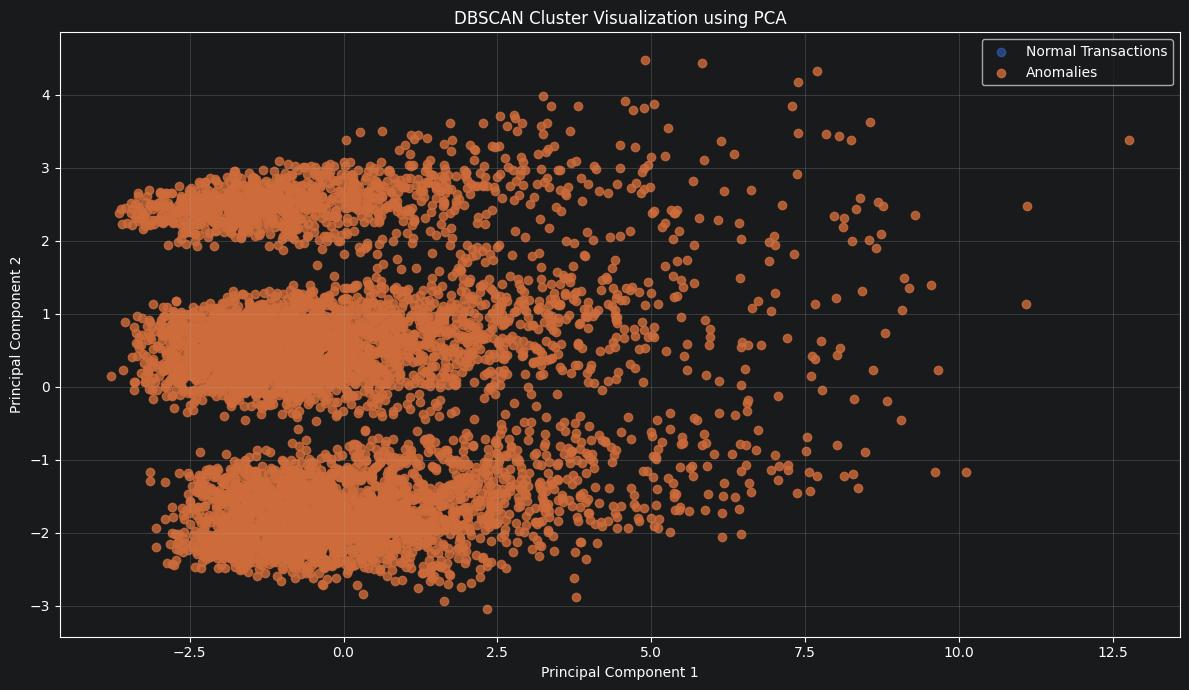

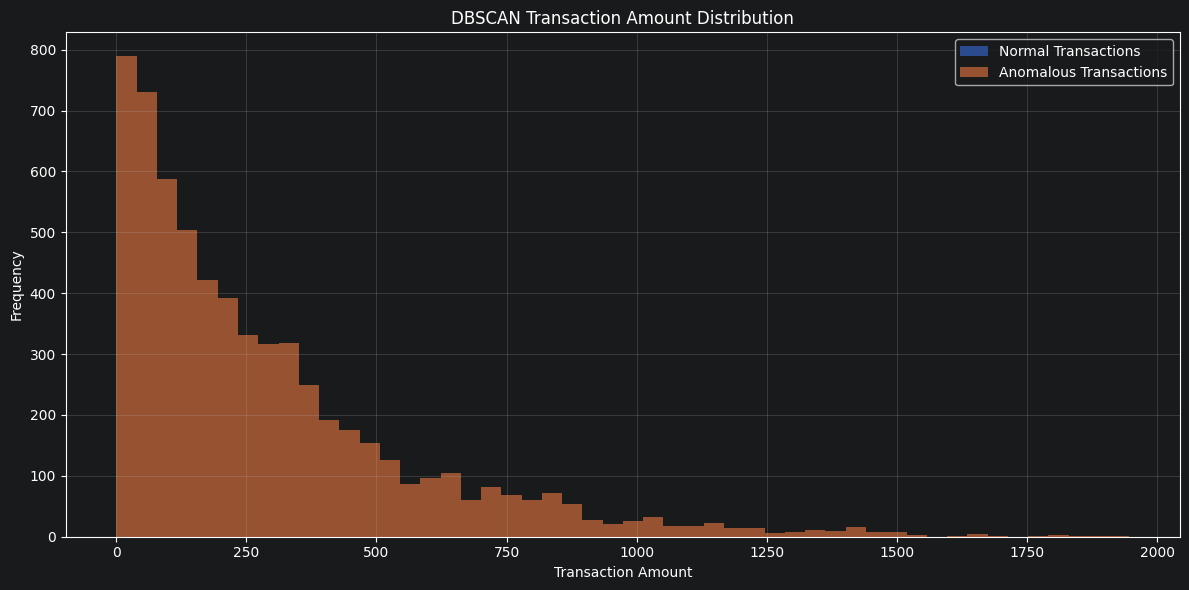


LOCATION-WISE ANOMALIES
Location
Philadelphia        181
Charlotte           178
Tucson              173
Omaha               173
Oklahoma City       173
Memphis             171
Indianapolis        170
Fort Worth          168
Denver              161
Boston              160
Los Angeles         158
Seattle             154
Mesa                153
Austin              153
Houston             152
Nashville           152
Miami               150
Jacksonville        149
San Diego           148
Chicago             146
Fresno              146
Raleigh             145
Atlanta             145
Detroit             144
Columbus            142
Kansas City         142
Milwaukee           142
San Jose            142
San Antonio         141
Colorado Springs    139
Sacramento          138
San Francisco       137
Washington          135
New York            135
Virginia Beach      133
Phoenix             127
Las Vegas           126
Louisville          120
Dallas              116
Baltimore           112
Portla

In [10]:
# =========================================================
# VERIFY INPUT DATA
# =========================================================

print("\n====================================")
print("DBSCAN INPUT DATA")
print("====================================")

print(f"X_standard Shape: {X_standard.shape}")

# =========================================================
# SELECT CORRECT INPUT FOR DBSCAN
# =========================================================
# BEST PRACTICE:
# Using LSTM latent features if available (recommended)

try:
    X_dbscan_input = X_latent  # from LSTM encoder
    print("\nUsing LSTM Latent Features for DBSCAN")
except NameError:
    X_dbscan_input = X_standard
    print("\nUsing Standard Features for DBSCAN (fallback)")

print(f"DBSCAN Input Shape: {X_dbscan_input.shape}")

# =========================================================
# BUILD DBSCAN MODEL
# =========================================================

dbscan = DBSCAN(
    eps=1.5,
    min_samples=10,
    metric='euclidean',
    n_jobs=-1
)

# =========================================================
# TRAIN DBSCAN MODEL
# =========================================================

print("\n====================================")
print("TRAINING DBSCAN MODEL")
print("====================================")

dbscan.fit(X_dbscan_input)

# =========================================================
# GET CLUSTER LABELS
# =========================================================

dbscan_labels = dbscan.labels_

# =========================================================
# DETECT ANOMALIES
# =========================================================

dbscan_anomalies = (dbscan_labels == -1)

# =========================================================
# ALIGN DATAFRAME SAFELY
# =========================================================

df_dbscan = df.iloc[:len(dbscan_labels)].copy()

df_dbscan['DBSCAN_Cluster'] = dbscan_labels
df_dbscan['DBSCAN_Anomaly'] = dbscan_anomalies.astype(int)

# =========================================================
# CALCULATE RESULTS
# =========================================================

total_anomalies = np.sum(dbscan_anomalies)

anomaly_percentage = np.mean(dbscan_anomalies) * 100

total_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

# =========================================================
# DISPLAY RESULTS
# =========================================================

print("\n====================================")
print("DBSCAN RESULTS")
print("====================================")

print(f"Total Transactions: {len(df_dbscan)}")
print(f"Clusters Found: {total_clusters}")
print(f"Anomalies Detected: {total_anomalies}")
print(f"Anomaly Percentage: {anomaly_percentage:.2f}%")

# =========================================================
# CREATE RESULT DATAFRAME
# =========================================================

dbscan_results = df_dbscan[[
    'DBSCAN_Cluster',
    'DBSCAN_Anomaly'
]].copy()

print("\n====================================")
print("DBSCAN RESULT PREVIEW")
print("====================================")

print(dbscan_results.head())

# =========================================================
# PCA VISUALIZATION (CORRECTED)
# =========================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_dbscan_input)

plt.figure(figsize=(12, 7))

# Normal points
plt.scatter(
    X_pca[~dbscan_anomalies, 0],
    X_pca[~dbscan_anomalies, 1],
    alpha=0.5,
    label='Normal Transactions'
)

# Anomalies
plt.scatter(
    X_pca[dbscan_anomalies, 0],
    X_pca[dbscan_anomalies, 1],
    alpha=0.8,
    label='Anomalies'
)

plt.title('DBSCAN Cluster Visualization using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# TRANSACTION AMOUNT DISTRIBUTION
# =========================================================

plt.figure(figsize=(12, 6))

plt.hist(
    df_dbscan.loc[~dbscan_anomalies, 'TransactionAmount'],
    bins=50,
    alpha=0.6,
    label='Normal Transactions'
)

plt.hist(
    df_dbscan.loc[dbscan_anomalies, 'TransactionAmount'],
    bins=50,
    alpha=0.7,
    label='Anomalous Transactions'
)

plt.title('DBSCAN Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# LOCATION-WISE ANOMALY ANALYSIS
# =========================================================

location_anomalies = (
    df_dbscan.groupby('Location')['DBSCAN_Anomaly']
    .sum()
    .sort_values(ascending=False)
)

print("\n====================================")
print("LOCATION-WISE ANOMALIES")
print("====================================")
print(location_anomalies)

# =========================================================
# CHANNEL-WISE ANOMALY ANALYSIS
# =========================================================

channel_anomalies = (
    df_dbscan.groupby('Channel')['DBSCAN_Anomaly']
    .sum()
    .sort_values(ascending=False)
)

print("\n====================================")
print("CHANNEL-WISE ANOMALIES")
print("====================================")
print(channel_anomalies)

# =========================================================
# TOP ANOMALOUS TRANSACTIONS
# =========================================================

top_dbscan_anomalies = df_dbscan[df_dbscan['DBSCAN_Anomaly'] == 1]

print("\n====================================")
print("TOP DBSCAN ANOMALIES")
print("====================================")

print(
    top_dbscan_anomalies[[
        'TransactionAmount',
        'AccountBalance',
        'LoginAttempts',
        'TransactionType',
        'Channel',
        'Location'
    ]].head(10)
)

# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n====================================")
print("DBSCAN MODEL COMPLETED")
print("====================================")

print("""
DBSCAN Successfully Completed:

1. Cluster Detection
2. Noise/Anomaly Detection
3. PCA Visualization
4. Location Analysis
5. Channel Analysis
6. Transaction Analysis
""")

# =========================================================
# LOCAL OUTLIER FACTOR (LOF) ANOMALY DETECTION
# =========================================================


LOF INPUT DATA
Using Standard Features for LOF (fallback)
LOF Input Shape: (6250, 65)

TRAINING LOF MODEL

LOF RESULTS
Total Transactions: 6250
Anomalies Detected: 313
Anomaly Percentage: 5.01%

LOF RESULT PREVIEW
      LOF_Score  LOF_Anomaly
3677   1.001683            0
2922   1.092222            0
5766   1.050634            0
3309   1.064333            0
1312   1.006892            0


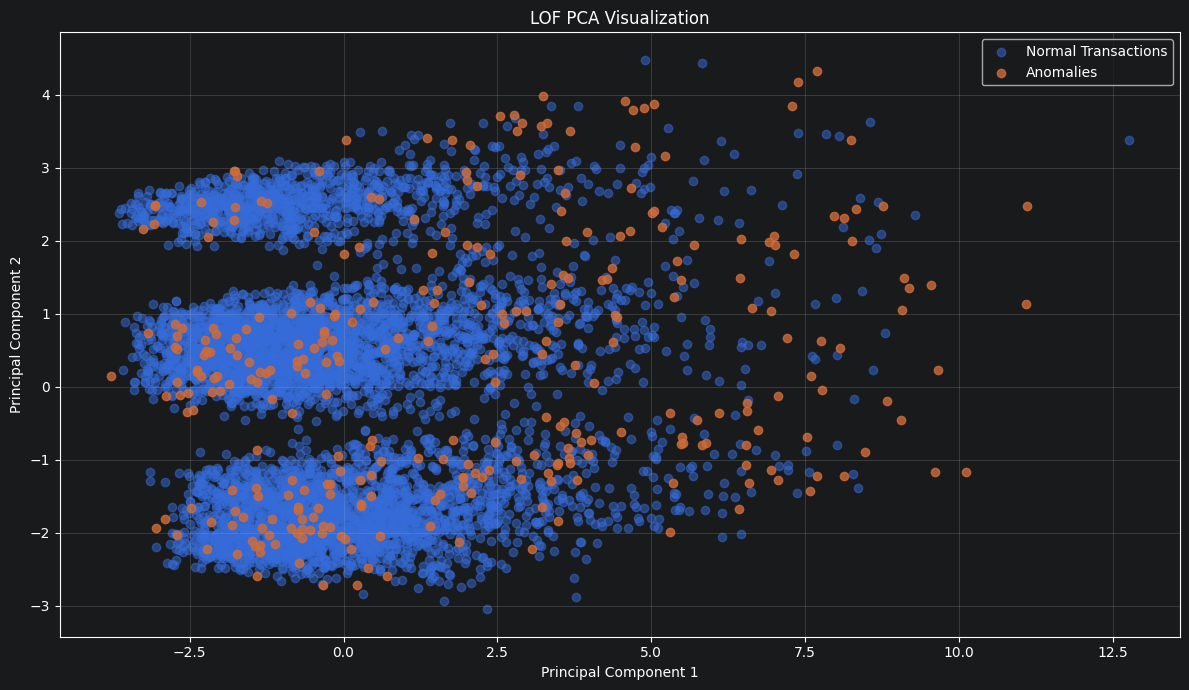

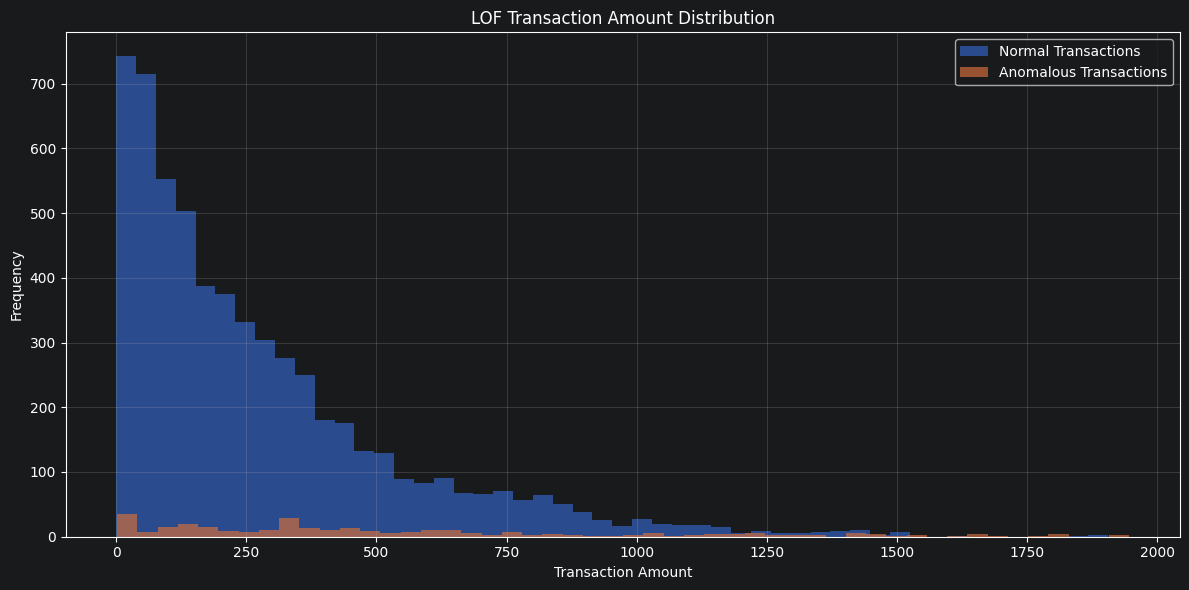


LOCATION-WISE LOF ANOMALIES
Location
Los Angeles         17
New York            14
Houston             13
Oklahoma City       12
Denver              11
Philadelphia        10
Sacramento          10
Fresno              10
Milwaukee           10
Baltimore           10
Austin              10
Nashville            9
Miami                9
Seattle              9
Omaha                9
Kansas City          9
Charlotte            9
Indianapolis         8
Detroit              8
San Diego            7
Fort Worth           7
San Antonio          7
San Jose             7
Mesa                 7
Louisville           7
Colorado Springs     7
Washington           6
Tucson               6
El Paso              6
Raleigh              5
Las Vegas            5
Boston               5
Chicago              5
Memphis              5
Phoenix              5
Portland             5
Columbus             4
Dallas               4
Atlanta              3
Jacksonville         3
Albuquerque          0
San Francisco      

In [11]:

# =========================================================
# SELECT CORRECT INPUT 
# =========================================================

print("\n====================================")
print("LOF INPUT DATA")
print("====================================")

try:
    X_lof_input = X_latent   # preferred (LSTM embeddings)
    print("Using LSTM Latent Features for LOF")
except NameError:
    X_lof_input = X_standard
    print("Using Standard Features for LOF (fallback)")

print(f"LOF Input Shape: {X_lof_input.shape}")

# =========================================================
# BUILD LOF MODEL
# =========================================================

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    metric='euclidean',
    novelty=False,
    n_jobs=-1
)

# =========================================================
# TRAIN LOF MODEL
# =========================================================

print("\n====================================")
print("TRAINING LOF MODEL")
print("====================================")

lof_predictions = lof.fit_predict(X_lof_input)

# =========================================================
# DETECT ANOMALIES
# =========================================================

lof_anomalies = (lof_predictions == -1)

# =========================================================
# LOF SCORES
# =========================================================

lof_scores = -lof.negative_outlier_factor_

# =========================================================
# ALIGNING DATAFRAME SAFELY 
# =========================================================

df_lof = df.iloc[:len(lof_predictions)].copy()

df_lof['LOF_Anomaly'] = lof_anomalies.astype(int)
df_lof['LOF_Score'] = lof_scores

# =========================================================
# METRICS
# =========================================================

total_anomalies = np.sum(lof_anomalies)
anomaly_percentage = np.mean(lof_anomalies) * 100

print("\n====================================")
print("LOF RESULTS")
print("====================================")

print(f"Total Transactions: {len(df_lof)}")
print(f"Anomalies Detected: {total_anomalies}")
print(f"Anomaly Percentage: {anomaly_percentage:.2f}%")

# =========================================================
# RESULT DATAFRAME
# =========================================================

lof_results = df_lof[['LOF_Score', 'LOF_Anomaly']].copy()

print("\n====================================")
print("LOF RESULT PREVIEW")
print("====================================")

print(lof_results.head())

# =========================================================
# PCA VISUALIZATION 
# =========================================================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_lof_input)

plt.figure(figsize=(12, 7))

plt.scatter(
    X_pca[~lof_anomalies, 0],
    X_pca[~lof_anomalies, 1],
    alpha=0.5,
    label='Normal Transactions'
)

plt.scatter(
    X_pca[lof_anomalies, 0],
    X_pca[lof_anomalies, 1],
    alpha=0.8,
    label='Anomalies'
)

plt.title('LOF PCA Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# TRANSACTION AMOUNT DISTRIBUTION
# =========================================================

plt.figure(figsize=(12, 6))

plt.hist(
    df_lof.loc[~lof_anomalies, 'TransactionAmount'],
    bins=50,
    alpha=0.6,
    label='Normal Transactions'
)

plt.hist(
    df_lof.loc[lof_anomalies, 'TransactionAmount'],
    bins=50,
    alpha=0.7,
    label='Anomalous Transactions'
)

plt.title('LOF Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# LOCATION ANALYSIS
# =========================================================

location_lof = (
    df_lof.groupby('Location')['LOF_Anomaly']
    .sum()
    .sort_values(ascending=False)
)

print("\n====================================")
print("LOCATION-WISE LOF ANOMALIES")
print("====================================")
print(location_lof)

# =========================================================
# CHANNEL ANALYSIS
# =========================================================

channel_lof = (
    df_lof.groupby('Channel')['LOF_Anomaly']
    .sum()
    .sort_values(ascending=False)
)

print("\n====================================")
print("CHANNEL-WISE LOF ANOMALIES")
print("====================================")
print(channel_lof)

# =========================================================
# TOP ANOMALIES
# =========================================================

top_lof_anomalies = df_lof[df_lof['LOF_Anomaly'] == 1].sort_values(
    by='LOF_Score',
    ascending=False
)

print("\n====================================")
print("TOP LOF ANOMALIES")
print("====================================")

print(
    top_lof_anomalies[[
        'TransactionAmount',
        'AccountBalance',
        'LoginAttempts',
        'TransactionType',
        'Channel',
        'Location',
        'LOF_Score'
    ]].head(10)
)

# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n====================================")
print("LOF MODEL COMPLETED")
print("====================================")

print("""
LOF Successfully Completed:

1. Density-Based Detection
2. LOF Scoring
3. PCA Visualization
4. Transaction Analysis
5. Location Analysis
6. Channel Analysis
7. Fraud Ranking
""")


Isolation Forest PERFORMANCE
Number of Anomalies: 313
Anomaly Rate: 5.01%
Transaction Amount - Normal: 265.91 ± 502.11
Transaction Amount - Anomalies: 782.28 ± 502.11
Average Login Attempts - Normal: 1.09
Average Login Attempts - Anomalies: 1.84
Unique Channels: 3
Unique Locations: 43
Avg Transaction Duration: 135.85
Avg Account Balance: 3208.67

DBSCAN PERFORMANCE
Number of Anomalies: 6250
Anomaly Rate: 100.00%
Transaction Amount - Normal: nan ± 289.04
Transaction Amount - Anomalies: 291.77 ± 289.04
Average Login Attempts - Normal: nan
Average Login Attempts - Anomalies: 1.12
Unique Channels: 3
Unique Locations: 43
Avg Transaction Duration: 118.73
Avg Account Balance: 5124.28

LOF PERFORMANCE
Number of Anomalies: 313
Anomaly Rate: 5.01%
Transaction Amount - Normal: 279.63 ± 467.10
Transaction Amount - Anomalies: 522.02 ± 467.10
Average Login Attempts - Normal: 1.04
Average Login Attempts - Anomalies: 2.60
Unique Channels: 3
Unique Locations: 40
Avg Transaction Duration: 133.33
Avg Ac

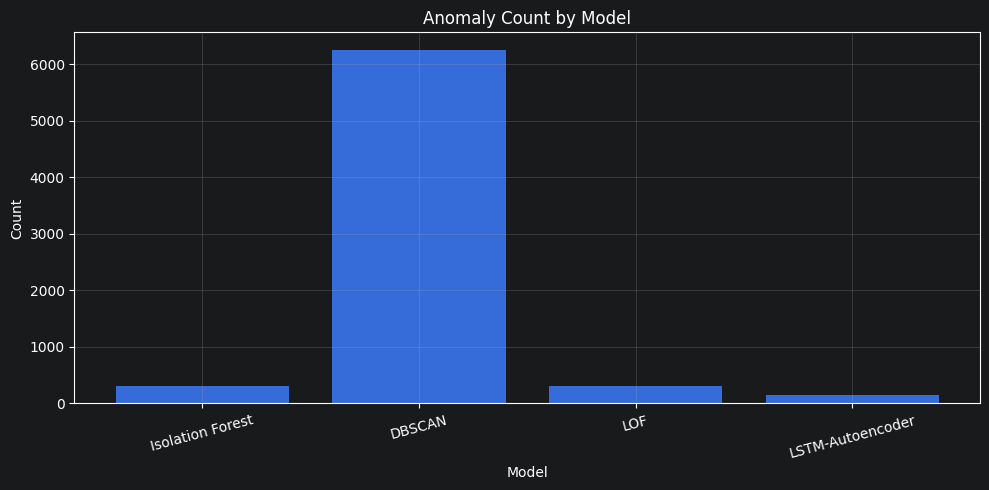

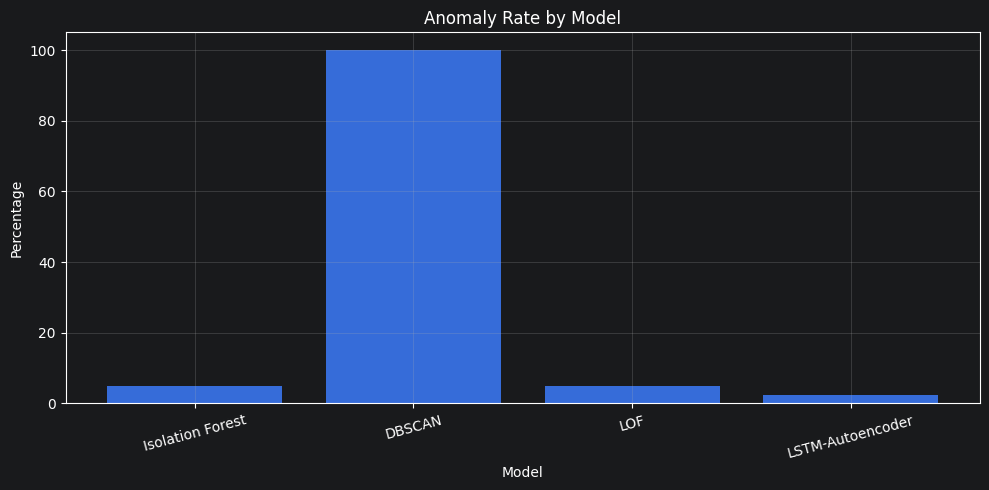


BEST MODEL
Selected Best Model: LSTM-Autoencoder


In [12]:
# =========================================================
# MODEL EVALUATION FUNCTION 
# =========================================================
def evaluate_models(anomaly_results, df, numeric_features):

    results = {}

    for model_name, anomalies in anomaly_results.items():

        # =================================================
        # CONVERT TO NUMPY ARRAY
        # =================================================

        anomalies = np.array(anomalies).astype(bool)

        # =================================================
        # SAFE ALIGNMENT (CRITICAL FIX)
        # =================================================

        if len(anomalies) != len(df):
            print(
                f"Aligning {model_name}: "
                f"{len(anomalies)} → {len(df)}"
            )

            aligned = np.zeros(len(df), dtype=bool)

            min_len = min(len(df), len(anomalies))

            aligned[:min_len] = anomalies[:min_len]

            anomalies = aligned

        # =================================================
        # SPLIT DATA
        # =================================================

        normal_data = df[~anomalies]
        anomaly_data = df[anomalies]

        # =================================================
        # HANDLE EMPTY CASE
        # =================================================

        if len(anomaly_data) == 0:
            print(f"No anomalies detected for {model_name}")
            continue

        # =================================================
        # SAFE FEATURE ACCESS CHECK
        # =================================================

        def safe_mean(col):
            return anomaly_data[col].mean() if col in df.columns else np.nan

        def safe_mean_normal(col):
            return normal_data[col].mean() if col in df.columns else np.nan

        def safe_std(col):
            return anomaly_data[col].std() if col in df.columns else np.nan

        # =================================================
        # METRICS CALCULATION
        # =================================================

        results[model_name] = {

            'num_anomalies': np.sum(anomalies),

            'anomaly_rate': np.mean(anomalies) * 100,

            # Financial behavior
            'normal_amount_mean': safe_mean_normal('TransactionAmount'),
            'anomaly_amount_mean': safe_mean('TransactionAmount'),

            'normal_amount_std': safe_std('TransactionAmount'),
            'anomaly_amount_std': safe_std('TransactionAmount'),

            # Behavioral signals
            'avg_login_attempts': safe_mean('LoginAttempts'),
            'normal_avg_login_attempts': safe_mean_normal('LoginAttempts'),

            # Diversity signals
            'unique_channels': anomaly_data['Channel'].nunique() if 'Channel' in df.columns else 0,
            'unique_locations': anomaly_data['Location'].nunique() if 'Location' in df.columns else 0,

            # Temporal/behavioral
            'avg_transaction_duration': safe_mean('TransactionDuration'),
            'avg_account_balance': safe_mean('AccountBalance')
        }

    return results

# =========================================================
# CREATING ANOMALY RESULT DICTIONARY (SAFE INPUTS)
# =========================================================

anomaly_results = {

    'Isolation Forest': iso_forest_anomalies,
    'DBSCAN': dbscan_anomalies,
    'LOF': lof_anomalies
}

# =========================================================
# ADDING LSTM 
# =========================================================

# SAFE ALIGNMENT FOR LSTM 
lstm_aligned = np.zeros(len(df), dtype=bool)

if 'lstm_autoencoder_anomalies' in globals():

    lstm_flags = np.array(lstm_autoencoder_anomalies).astype(bool)

    #sequence-based alignment
    start = len(df) - len(lstm_flags)

    lstm_aligned[start:] = lstm_flags

    anomaly_results['LSTM-Autoencoder'] = lstm_aligned

# =========================================================
# RUN EVALUATION
# =========================================================

evaluation_results = evaluate_models(
    anomaly_results,
    df,
    numeric_features
)

# =========================================================
# PRINT RESULTS
# =========================================================

for model_name, metrics in evaluation_results.items():

    print(f"\n{'=' * 60}")
    print(f"{model_name} PERFORMANCE")
    print(f"{'=' * 60}")

    print(f"Number of Anomalies: {metrics['num_anomalies']}")
    print(f"Anomaly Rate: {metrics['anomaly_rate']:.2f}%")

    print(f"Transaction Amount - Normal: "
          f"{metrics['normal_amount_mean']:.2f} ± {metrics['normal_amount_std']:.2f}")

    print(f"Transaction Amount - Anomalies: "
          f"{metrics['anomaly_amount_mean']:.2f} ± {metrics['anomaly_amount_std']:.2f}")

    print(f"Average Login Attempts - Normal: {metrics['normal_avg_login_attempts']:.2f}")
    print(f"Average Login Attempts - Anomalies: {metrics['avg_login_attempts']:.2f}")

    print(f"Unique Channels: {metrics['unique_channels']}")
    print(f"Unique Locations: {metrics['unique_locations']}")

    print(f"Avg Transaction Duration: {metrics['avg_transaction_duration']:.2f}")
    print(f"Avg Account Balance: {metrics['avg_account_balance']:.2f}")

# =========================================================
# SUMMARY TABLE
# =========================================================

evaluation_df = pd.DataFrame(evaluation_results).T

print("\n================================")
print("EVALUATION SUMMARY TABLE")
print("================================")

print(evaluation_df)

# =========================================================
# VISUALIZATION - ANOMALY COUNT
# =========================================================

plt.figure(figsize=(10, 5))

plt.bar(evaluation_df.index, evaluation_df['num_anomalies'])

plt.title('Anomaly Count by Model')
plt.xlabel('Model')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# VISUALIZATION - ANOMALY RATE
# =========================================================

plt.figure(figsize=(10, 5))

plt.bar(evaluation_df.index, evaluation_df['anomaly_rate'])

plt.title('Anomaly Rate by Model')
plt.xlabel('Model')
plt.ylabel('Percentage')
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# BEST MODEL SELECTION
# =========================================================

best_model = evaluation_df['anomaly_rate'].idxmin()

print("\n================================")
print("BEST MODEL")
print("================================")

print(f"Selected Best Model: {best_model}")

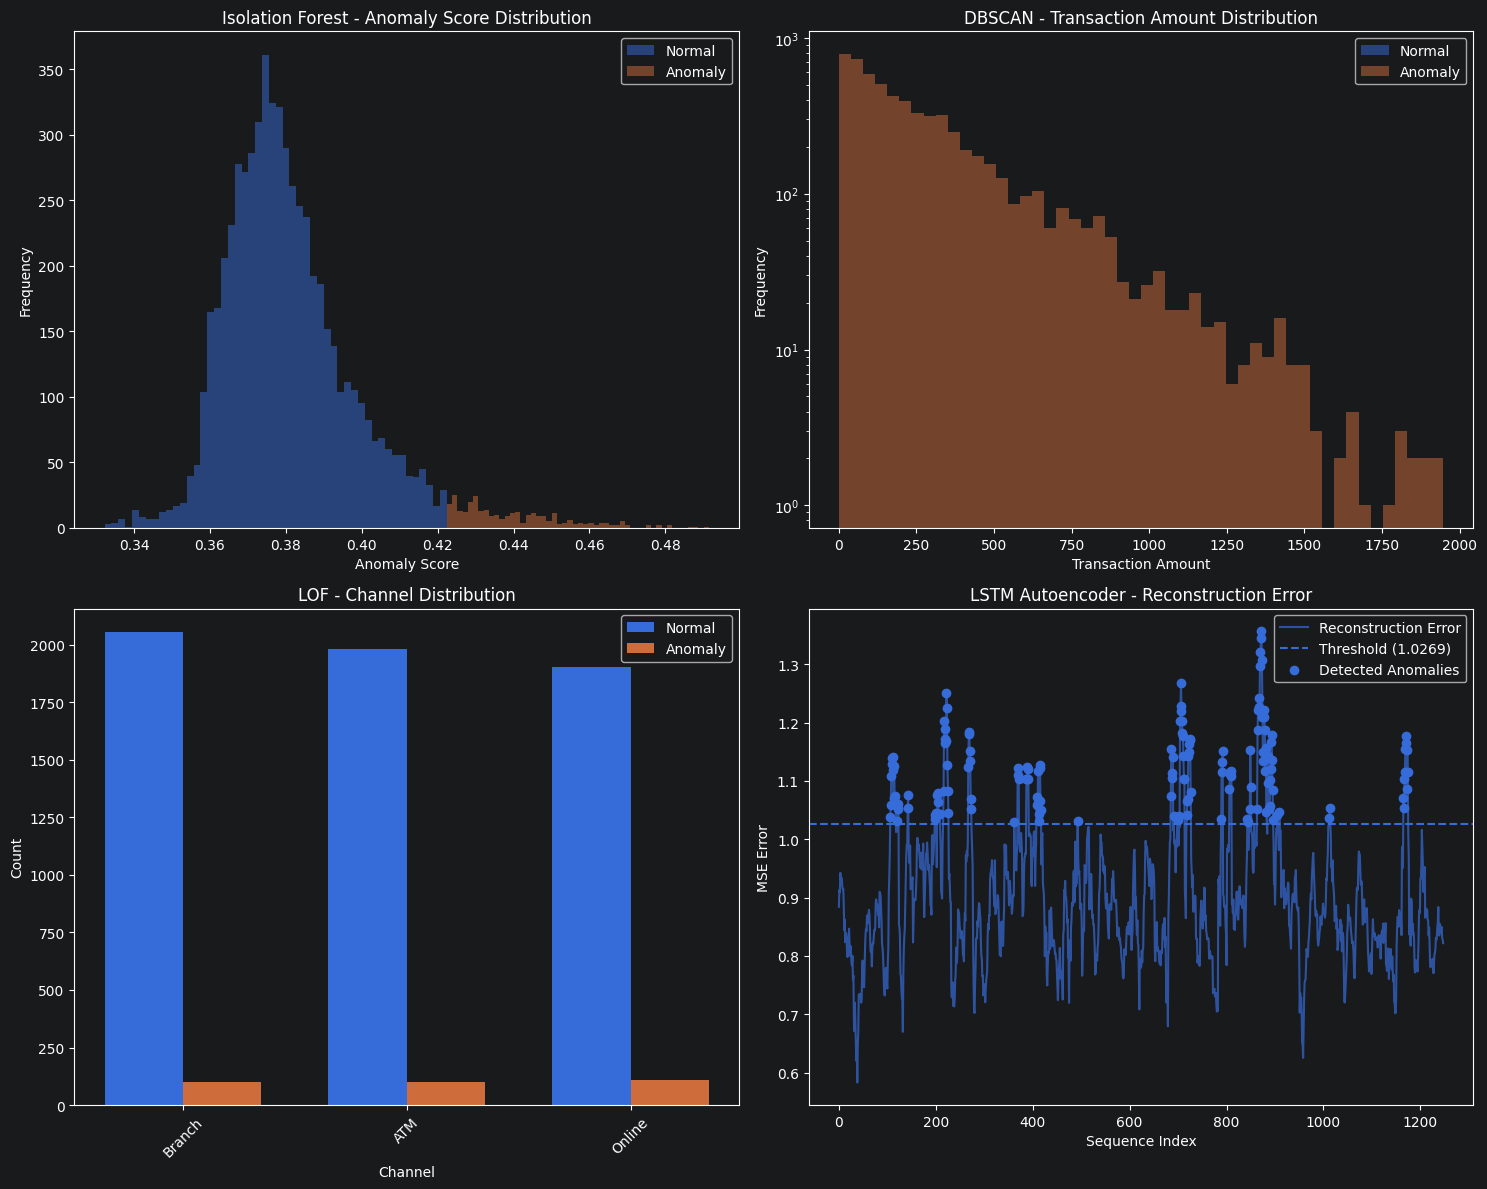

In [13]:
# =========================================================
# ADVANCED ANOMALY VISUALIZATIONS 
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# =========================================================
# SAFE BOOLEAN CONVERSION
# =========================================================

iso_forest_anomalies_bool = np.array(iso_forest_anomalies).astype(bool)
dbscan_anomalies_bool = np.array(dbscan_anomalies).astype(bool)
lof_anomalies_bool = np.array(lof_anomalies).astype(bool)

# =========================================================
# SAFE INPUT SELECTION FOR ISOLATION FOREST SCORES
# =========================================================

X_iso_input = X_latent if 'X_latent' in globals() else X_standard

iso_scores = -iso_forest.score_samples(X_iso_input)

# =========================================================
# ALIGN DATAFRAME SAFELY
# =========================================================

df_viz = df.iloc[:len(iso_forest_anomalies_bool)].copy()

# =========================================================
# 1. ISOLATION FOREST SCORE DISTRIBUTION
# =========================================================

axes[0, 0].hist(
    iso_scores[~iso_forest_anomalies_bool],
    bins=50,
    alpha=0.5,
    label='Normal'
)

axes[0, 0].hist(
    iso_scores[iso_forest_anomalies_bool],
    bins=50,
    alpha=0.5,
    label='Anomaly'
)

axes[0, 0].set_title('Isolation Forest - Anomaly Score Distribution')
axes[0, 0].set_xlabel('Anomaly Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# =========================================================
# 2. DBSCAN TRANSACTION AMOUNT DISTRIBUTION
# =========================================================

dbscan_normal = df_viz.loc[~dbscan_anomalies_bool, 'TransactionAmount']
dbscan_anomaly = df_viz.loc[dbscan_anomalies_bool, 'TransactionAmount']

axes[0, 1].hist(dbscan_normal, bins=50, alpha=0.5, label='Normal')
axes[0, 1].hist(dbscan_anomaly, bins=50, alpha=0.5, label='Anomaly')

axes[0, 1].set_title('DBSCAN - Transaction Amount Distribution')
axes[0, 1].set_xlabel('Transaction Amount')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_yscale('log')
axes[0, 1].legend()

# =========================================================
# 3. LOF CHANNEL DISTRIBUTION
# =========================================================

channel_counts_normal = df_viz.loc[~lof_anomalies_bool, 'Channel'].value_counts().head(10)
channel_counts_anomaly = df_viz.loc[lof_anomalies_bool, 'Channel'].value_counts().reindex(
    channel_counts_normal.index,
    fill_value=0
)

x_pos = np.arange(len(channel_counts_normal.index))
width = 0.35

axes[1, 0].bar(
    x_pos - width / 2,
    channel_counts_normal.values,
    width,
    label='Normal'
)

axes[1, 0].bar(
    x_pos + width / 2,
    channel_counts_anomaly.values,
    width,
    label='Anomaly'
)

axes[1, 0].set_title('LOF - Channel Distribution')
axes[1, 0].set_xlabel('Channel')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(channel_counts_normal.index, rotation=45)
axes[1, 0].legend()

# =========================================================
# 4. LSTM RECONSTRUCTION ERROR OVER TIME 
# =========================================================

if (
    'lstm_autoencoder_anomalies' in globals() and
    'val_mse' in globals() and
    'threshold' in globals()
):

    reconstruction_errors = np.array(val_mse)

    # Safe sequence index mapping
    seq_indices = np.arange(len(reconstruction_errors))

    axes[1, 1].plot(
        seq_indices,
        reconstruction_errors,
        alpha=0.7,
        label='Reconstruction Error'
    )

    axes[1, 1].axhline(
        y=threshold,
        linestyle='--',
        label=f'Threshold ({threshold:.4f})'
    )

    # anomaly positions
    anomaly_mask = np.array(lstm_autoencoder_anomalies).astype(bool)

    axes[1, 1].scatter(
        seq_indices[anomaly_mask],
        reconstruction_errors[anomaly_mask],
        label='Detected Anomalies'
    )

    axes[1, 1].set_title('LSTM Autoencoder - Reconstruction Error')
    axes[1, 1].set_xlabel('Sequence Index')
    axes[1, 1].set_ylabel('MSE Error')
    axes[1, 1].legend()

# =========================================================
# FINAL LAYOUT
# =========================================================

plt.tight_layout()
plt.show()

## Isolation Forest

Isolation Forest mainly looks for data points that are very different from the rest. So it naturally flags only a small number of transactions as unusual, which is why the anomaly rate is low. If we notice that these flagged transactions usually have much higher amounts, it means the model is picking up rare, high-value transactions. These could be suspicious, but they still need further checking before calling them fraud.
### Explanation:
Isolation Forest detects anomalies by isolating observations that differ significantly from the majority of the dataset. The anomaly score distribution shows that most transactions behave normally, while only a small number lie in the higher anomaly score region. This indicates that the dataset contains relatively few extreme outliers. Transactions with higher scores may represent suspicious or unusually large financial activities and should be further investigated for potential fraud.

## DBSCAN

DBSCAN works by grouping similar transactions together based on density. Anything that doesn’t fit into a group is treated as noise or an anomaly. This means it is good at detecting fraud when fraud transactions happen in clusters, like fraud rings. But if fraud transactions are scattered and never form a pattern, DBSCAN may miss them or label them as noise without clearly separating them.

### Explanation :
DBSCAN identifies anomalies based on density differences in the dataset. Transactions that do not belong to any dense cluster are labeled as anomalies or noise points. The distribution indicates that anomalous transactions are sparse and scattered across different transaction amounts. DBSCAN is effective when fraudulent transactions form dense behavioral clusters, such as coordinated fraud rings. However, isolated fraud cases that do not form clusters may either be missed or simply treated as generic noise points.

## Local Outlier Factor (LOF)

LOF focuses on how different a transaction is compared to its nearby neighbors. So it is more about local behavior than overall data trends. If LOF finds fewer anomalies compared to Isolation Forest, it usually means the unusual transactions are not just “local weird cases” but are unusual in a broader sense across the dataset. This helps us understand whether fraud is local or global in nature.

### Explanation :
Local Outlier Factor (LOF) detects anomalies by comparing the local density of a transaction with the density of its neighboring transactions. Transactions that significantly differ from their local neighborhood receive higher anomaly scores. The channel distribution graph shows that anomalies are present across Branch, ATM, and Online channels, indicating that unusual behavior occurs in multiple transaction environments rather than being limited to a single transaction source.

## LSTM Autoencoder

LSTM Autoencoder is used for sequential data, so it learns normal patterns of transactions over time. If a transaction sequence doesn’t match what the model has learned, it shows a high reconstruction error and is marked as an anomaly. If we use a very strict threshold, more transactions get flagged. Also, if we see multiple anomalies happening one after another, it can indicate coordinated fraud behavior like money mule activity or organized fraud patterns.

### Explanation :
The LSTM Autoencoder learns normal sequential transaction behavior over time. Transactions or transaction sequences that deviate significantly from learned patterns produce higher reconstruction errors. In the graph, anomalies are identified when reconstruction error exceeds the threshold value. Consecutive spikes above the threshold may indicate periods of abnormal or coordinated transaction activity, which could correspond to organized fraud behavior or suspicious transaction bursts.

# =========================================================
# SAVING MODELS
# =========================================================

In [14]:
# =========================================================
# CREATE MODELS DIRECTORY
# =========================================================

# Creates folder if not present
os.makedirs(
    'models',
    exist_ok=True
)

print("\n===================================")
print("MODELS DIRECTORY READY")
print("===================================")

# =========================================================
# VERIFY REQUIRED OBJECTS EXIST
# =========================================================

required_objects = {

    'iso_forest': 'Isolation Forest Model',

    'scaler_standard': 'Standard Scaler',

    'X_combined': 'Feature Dataset',

    'lstm_autoencoder': 'LSTM Autoencoder Model'
}

missing_objects = []

for obj_name, description in required_objects.items():
    if obj_name not in globals():
        missing_objects.append(description)

# =========================================================
# HANDLE MISSING OBJECTS
# =========================================================

if len(missing_objects) > 0:
    print("\n===================================")
    print("ERROR: REQUIRED OBJECTS MISSING")
    print("===================================")
    for item in missing_objects:
        print(f"Missing -> {item}")
    print("\nTrain models before saving.")
else:
    print("\n===================================")
    print("ALL REQUIRED OBJECTS FOUND")
    print("===================================")

    # =====================================================
    # SAVE ISOLATION FOREST MODEL
    # =====================================================

    try:
        joblib.dump(
            iso_forest,
            'models/isolation_forest.pkl'
        )

        print(
            "\nIsolation Forest Model Saved Successfully"
        )

    except Exception as e:
        print(
            f"\nError Saving Isolation Forest: {e}"
        )

    # =====================================================
    # SAVE STANDARD SCALER
    # =====================================================

    try:
        joblib.dump(
            scaler_standard,
            'models/scaler_standard.pkl'
        )

        print(
            "Standard Scaler Saved Successfully"
        )

    except Exception as e:
        print(
            f"\nError Saving Scaler: {e}"
        )

    # =====================================================
    # SAVE FEATURE COLUMNS
    # =====================================================

    try:
        feature_columns = list(
            X_combined.columns
        )

        joblib.dump(
            feature_columns,
            'models/feature_columns.pkl'
        )

        print(
            "Feature Columns Saved Successfully"
        )

        print("\n===================================")
        print("TOTAL FEATURES")
        print("===================================")

        print(len(feature_columns))

    except Exception as e:
        print(
            f"\nError Saving Feature Columns: {e}"
        )

    # =====================================================
    # SAVE LSTM AUTOENCODER MODEL
    # =====================================================

    try:
        lstm_autoencoder.save(
            'models/lstm_autoencoder.keras'
        )

        print(
            "LSTM Autoencoder Saved Successfully"
        )
    except Exception as e:
        print(
            f"\nError Saving LSTM Model: {e}"
        )

    # =====================================================
    # VERIFY SAVED FILES
    # =====================================================

    print("\n===================================")
    print("VERIFYING SAVED FILES")
    print("===================================")

    saved_files = [
        'models/isolation_forest.pkl',
        'models/scaler_standard.pkl',
        'models/feature_columns.pkl',
        'models/lstm_autoencoder.keras'
    ]

    for file_path in saved_files:
        if os.path.exists(file_path):
            print(f"FOUND -> {file_path}")
        else:
            print(f"MISSING -> {file_path}")

    # =====================================================
    # TEST LOADING MODELS
    # =====================================================

    print("\n===================================")
    print("TESTING MODEL LOADING")
    print("===================================")

    try:
        loaded_iso = joblib.load(
            'models/isolation_forest.pkl'
        )
        loaded_scaler = joblib.load(
            'models/scaler_standard.pkl'
        )

        loaded_features = joblib.load(
            'models/feature_columns.pkl'
        )

        from tensorflow.keras.models import load_model

        loaded_lstm = load_model(
            'models/lstm_autoencoder.keras'
        )
        print(
            "\nALL MODELS LOADED SUCCESSFULLY"
        )

    except Exception as e:
        print(
            f"\nMODEL LOADING ERROR: {e}"
        )

# =========================================================
# FINAL MESSAGE
# =========================================================

print("\n===================================")
print("MODEL SAVING PROCESS COMPLETED")
print("===================================")


MODELS DIRECTORY READY

ALL REQUIRED OBJECTS FOUND

Isolation Forest Model Saved Successfully
Standard Scaler Saved Successfully
Feature Columns Saved Successfully

TOTAL FEATURES
65
LSTM Autoencoder Saved Successfully

VERIFYING SAVED FILES
FOUND -> models/isolation_forest.pkl
FOUND -> models/scaler_standard.pkl
FOUND -> models/feature_columns.pkl
FOUND -> models/lstm_autoencoder.keras

TESTING MODEL LOADING

ALL MODELS LOADED SUCCESSFULLY

MODEL SAVING PROCESS COMPLETED


# =========================================================
# CUSTOMER SEGMENTATION & RETENTION ANALYSIS 
# =========================================================


ALL REQUIRED COLUMNS FOUND

CUSTOMER PROFILE PREVIEW
           avg_amount  amount_std  transaction_count  avg_login  dbscan_risk  \
AccountID                                                                      
AC00001     82.566667   70.401790                  9   1.000000          0.0   
AC00002    325.446316  192.291774                 19   1.052632          0.0   
AC00003    278.390000  148.549030                 11   1.000000          0.0   
AC00004    237.329565  214.479008                 23   1.000000          0.0   
AC00005    349.563333  165.776329                 24   1.000000          0.0   
AC00006    169.340667  128.514422                 15   1.000000          0.0   
AC00007    312.212000  202.483092                 10   1.000000          0.0   
AC00008     76.160000    0.000000                  1   1.000000          0.0   
AC00009    190.199167  121.084506                 12   1.000000          0.0   
AC00010    463.986667  467.832852                 18   1.000000   

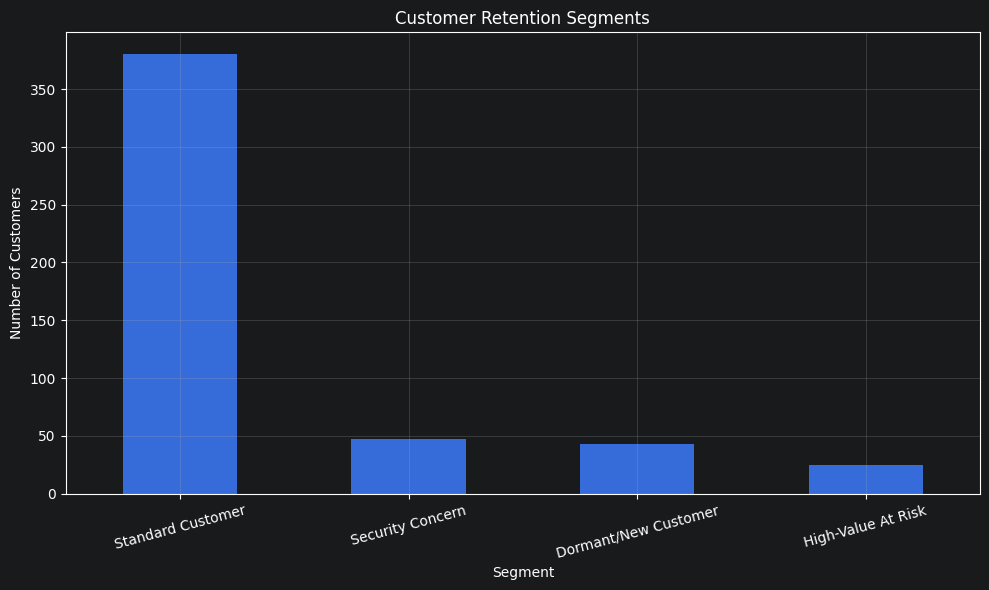

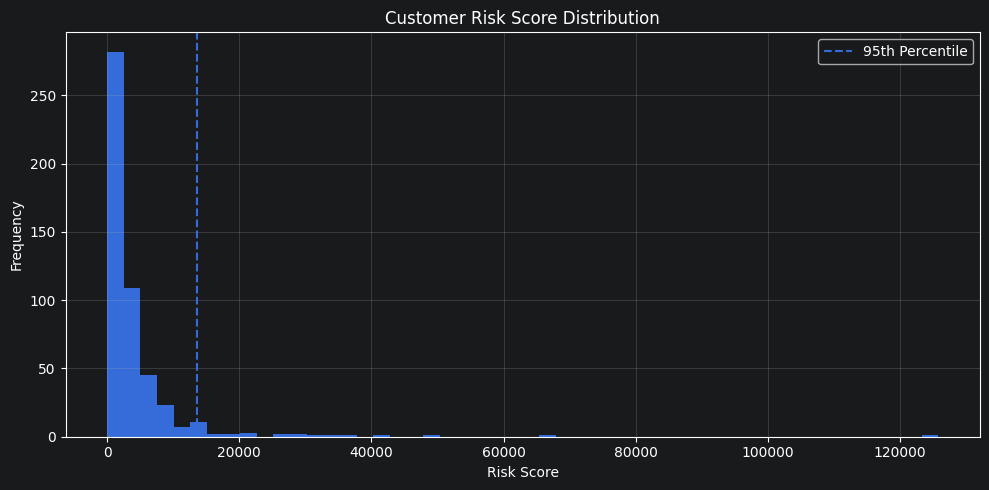


CUSTOMER RETENTION PROFILES SAVED
Saved File -> customer_retention_profiles.csv


In [15]:
# =========================================================
# VERIFY REQUIRED COLUMNS
# =========================================================

required_columns = [
    'AccountID',
    'TransactionAmount',
    'LoginAttempts',
    'TransactionType'
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:

    print("\n====================================")
    print("MISSING REQUIRED COLUMNS")
    print("====================================")
    print(missing_columns)

else:

    print("\n====================================")
    print("ALL REQUIRED COLUMNS FOUND")
    print("====================================")

    df = df.copy()

    # =====================================================
    # HANDLE MISSING VALUES SAFELY
    # =====================================================

    df['TransactionAmount'] = df['TransactionAmount'].fillna(0)
    df['LoginAttempts'] = df['LoginAttempts'].fillna(0)
    df['TransactionType'] = df['TransactionType'].fillna('Unknown')
    df['Channel'] = df['Channel'].fillna('Unknown') if 'Channel' in df.columns else 'Unknown'
    df['Location'] = df['Location'].fillna('Unknown') if 'Location' in df.columns else 'Unknown'

    # =====================================================
    # ADD ML SIGNALS (IF AVAILABLE)
    # =====================================================

    if 'DBSCAN_Anomaly' not in df.columns:
        df['DBSCAN_Anomaly'] = 0

    if 'LOF_Anomaly' not in df.columns:
        df['LOF_Anomaly'] = 0

    if 'LOF_Score' not in df.columns:
        df['LOF_Score'] = 0

    # =====================================================
    # CREATE CUSTOMER PROFILES
    # =====================================================

    customer_profiles = df.groupby('AccountID').agg({

        'TransactionAmount': ['mean', 'std', 'count'],
        'LoginAttempts': 'mean',
        'DBSCAN_Anomaly': 'mean',
        'LOF_Anomaly': 'mean',

        'TransactionType': lambda x: x.mode().iloc[0]
        if not x.mode().empty else 'Unknown'
    })

    # =====================================================
    # RENAME COLUMNS
    # =====================================================

    customer_profiles.columns = [
        'avg_amount',
        'amount_std',
        'transaction_count',
        'avg_login',
        'dbscan_risk',
        'lof_risk',
        'preferred_type'
    ]

    # =====================================================
    # HANDLE NaN VALUES
    # =====================================================

    customer_profiles['amount_std'] = customer_profiles['amount_std'].fillna(0)

    # =====================================================
    # SAFE RISK SCORE (STABLE VERSION)
    # =====================================================

    customer_profiles['risk_score'] = (
        customer_profiles['avg_amount'] *
        customer_profiles['amount_std']
    ) / (customer_profiles['transaction_count'] + 1e-6)

    # =====================================================
    # COMBINED ML RISK SIGNAL
    # =====================================================

    customer_profiles['ml_risk_score'] = (
        customer_profiles['dbscan_risk'] +
        customer_profiles['lof_risk']
    ) / 2

    # =====================================================
    # FINAL HYBRID RISK SCORE
    # =====================================================

    customer_profiles['final_risk_score'] = (
        customer_profiles['risk_score'] * 0.5 +
        customer_profiles['ml_risk_score'] * 0.5
    )

    # =====================================================
    # SEGMENT THRESHOLDS
    # =====================================================

    high_risk_threshold = customer_profiles['final_risk_score'].quantile(0.95)
    login_threshold = customer_profiles['avg_login'].quantile(0.90)

    # =====================================================
    # SEGMENTATION FUNCTION
    # =====================================================

    def assign_retention_segment(row):

        if row['final_risk_score'] > high_risk_threshold:
            return 'High-Value At Risk'

        elif row['avg_login'] > login_threshold:
            return 'Security Concern'

        elif row['transaction_count'] < 5:
            return 'Dormant/New Customer'

        else:
            return 'Standard Customer'

    # =====================================================
    # APPLY SEGMENTATION
    # =====================================================

    customer_profiles['retention_segment'] = customer_profiles.apply(
        assign_retention_segment,
        axis=1
    )

    # =====================================================
    # RETENTION STRATEGIES
    # =====================================================

    retention_strategies = {

        'High-Value At Risk': {
            'action': 'Proactive Outreach',
            'offer': 'Premium fraud protection + rewards',
            'communication': 'Dedicated manager',
            'expected_uplift': '15–20%'
        },

        'Security Concern': {
            'action': 'Security Education',
            'offer': 'Free security audit',
            'communication': 'Alerts via SMS/email',
            'expected_uplift': '10–15%'
        },

        'Dormant/New Customer': {
            'action': 'Engagement Campaign',
            'offer': 'Cashback incentives',
            'communication': 'Onboarding support',
            'expected_uplift': '20–25%'
        },

        'Standard Customer': {
            'action': 'Regular Monitoring',
            'offer': 'Loyalty rewards',
            'communication': 'Monthly insights',
            'expected_uplift': '5–10%'
        }
    }

    # =====================================================
    # MAP STRATEGIES
    # =====================================================

    customer_profiles['recommended_action'] = customer_profiles['retention_segment'].map(
        lambda x: retention_strategies[x]['action']
    )

    customer_profiles['recommended_offer'] = customer_profiles['retention_segment'].map(
        lambda x: retention_strategies[x]['offer']
    )

    customer_profiles['communication_plan'] = customer_profiles['retention_segment'].map(
        lambda x: retention_strategies[x]['communication']
    )

    customer_profiles['expected_uplift'] = customer_profiles['retention_segment'].map(
        lambda x: retention_strategies[x]['expected_uplift']
    )

    # =====================================================
    # OUTPUT PREVIEW
    # =====================================================

    print("\n====================================")
    print("CUSTOMER PROFILE PREVIEW")
    print("====================================")

    print(customer_profiles.head(10))

    # =====================================================
    # SEGMENT DISTRIBUTION
    # =====================================================

    plt.figure(figsize=(10, 6))
    customer_profiles['retention_segment'].value_counts().plot(kind='bar')

    plt.title('Customer Retention Segments')
    plt.xlabel('Segment')
    plt.ylabel('Number of Customers')
    plt.xticks(rotation=15)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # =====================================================
    # RISK SCORE DISTRIBUTION
    # =====================================================

    plt.figure(figsize=(10, 5))
    plt.hist(customer_profiles['final_risk_score'], bins=50)

    plt.axvline(high_risk_threshold, linestyle='--', label='95th Percentile')

    plt.title('Customer Risk Score Distribution')
    plt.xlabel('Risk Score')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # =====================================================
    # SAVE OUTPUT
    # =====================================================

    customer_profiles.to_csv(
        'customer_retention_profiles.csv'
    )

    print("\n====================================")
    print("CUSTOMER RETENTION PROFILES SAVED")
    print("====================================")

    print("Saved File -> customer_retention_profiles.csv")